# Master EDA

In [5]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## - Attendance

In [6]:
attendance = pd.read_csv("/Users/sa10/Downloads/Education-Capstone/data/public-school-attendance-results 2016-2021.csv")
attendance2 = pd.read_csv("/Users/sa10/Downloads/Education-Capstone/data/public-borough-attendance-results-2019-2024.csv")

In [7]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124525 entries, 0 to 124524
Data columns (total 13 columns):
 #   Column                                         Non-Null Count   Dtype 
---  ------                                         --------------   ----- 
 0   DBN                                            124525 non-null  object
 1   Borough                                        124525 non-null  object
 2   School Name                                    124525 non-null  object
 3   Grade                                          124525 non-null  object
 4   Category                                       124525 non-null  object
 5   Year                                           124525 non-null  object
 6   # Total Days                                   124525 non-null  object
 7   # Days Absent                                  124525 non-null  object
 8   # Days Present                                 124525 non-null  object
 9   % Attendance                                   1

In [8]:
# Change objects into integers
columns = [
    "Grade",
    "# Total Days",
    "# Days Absent",
    "# Days Present",
    "% Attendance",
    "# Contributing 10+ Total Days and 1+ Pres Day",
    "# Chronically Absent",
    "% Chronically Absent"
]

for col in columns:
    attendance[col] = pd.to_numeric(attendance[col], errors="coerce")    
    if "#" in col or "Grade" in col:
        attendance[col] = attendance[col].astype("Int64")

In [9]:
# Remove accidental header rows
df_clean = attendance[attendance["Borough"] != "Borough"]

# Define aggregation rules
agg_rules = {
    "# Total Days": "sum",
    "# Days Absent": "sum",
    "# Days Present": "sum",
    "% Attendance": "mean",
    "# Contributing 10+ Total Days and 1+ Pres Day": "sum",
    "# Chronically Absent": "sum",
    "% Chronically Absent": "mean"
}

# Group and aggregate values
agg_df = df_clean.groupby(["Borough", "Grade", "Category", "Year"], as_index=False).agg(agg_rules)

# Round percentages
agg_df["% Attendance"] = agg_df["% Attendance"].round(1)
agg_df["% Chronically Absent"] = agg_df["% Chronically Absent"].round(1)

# Sort values
agg_df = agg_df.sort_values(["Borough", "Grade", "Year"])

agg_df

,Borough,Grade,Category,Year,# Total Days,# Days Absent,# Days Present,% Attendance,# Contributing 10+ Total Days and 1+ Pres Day,# Chronically Absent,% Chronically Absent
0,Bronx,9,All Students,2016-17,2457812,393491,2048170,83.0,16073,6698,44.2
5,Bronx,9,Asian,2016-17,163278,4460,120388,91.6,786,70,28.9
10,Bronx,9,Black,2016-17,653201,99155,501435,83.7,3995,1713,43.0
15,Bronx,9,ELL,2016-17,539763,72537,355657,82.6,2908,1259,45.6
20,Bronx,9,Female,2016-17,1111506,163609,939548,84.1,7259,2852,42.0
...,...,...,...,...,...,...,...,...,...,...,...
1379,Staten Island,12,Not SWD,2020-21,576144,83738,492062,84.1,3337,1217,42.5
1384,Staten Island,12,Other,2020-21,11243,1764,4536,72.5,37,22,60.5
1389,Staten Island,12,Poverty,2020-21,439940,86757,353183,80.5,2574,1189,48.1
1394,Staten Island,12,SWD,2020-21,181873,39275,130638,79.1,995,526,49.8


In [10]:
# Filter df for years 
add_years = ["2016-17", "2017-18"]

df1 = agg_df[agg_df["Year"].isin(add_years)].copy()

# Concatenate to df2
edu_df = pd.concat([attendance2, df1], ignore_index=True)

# Remove accidental header rows
edu_df = edu_df[edu_df["Borough"] != "Borough"]

# Sort Values
edu_df = edu_df.sort_values(["Borough", "Grade", "Year"]).reset_index(drop=True)


edu_df

,Borough,Grade,Category,Year,# Total Days,# Days Absent,# Days Present,% Attendance,# Contributing 10+ Total Days and 1+ Pres Day,# Chronically Absent,% Chronically Absent
0,Bronx,9,All Students,2016-17,2457812,393491,2048170,83.0,16073,6698,44.2
1,Bronx,9,Asian,2016-17,163278,4460,120388,91.6,786,70,28.9
2,Bronx,9,Black,2016-17,653201,99155,501435,83.7,3995,1713,43.0
3,Bronx,9,ELL,2016-17,539763,72537,355657,82.6,2908,1259,45.6
4,Bronx,9,Female,2016-17,1111506,163609,939548,84.1,7259,2852,42.0
...,...,...,...,...,...,...,...,...,...,...,...
2275,Staten Island,9,Neither male nor female,2023-24,332,s,s,s,s,s,s
2276,Staten Island,9,Not Poverty,2023-24,225710,13724,211986,93.9,1386,189,13.6
2277,Staten Island,9,Poverty,2023-24,548735,73888,474847,86.5,3453,1234,35.7
2278,Staten Island,9,ELL,2023-24,60488,9587,50901,84.2,425,162,38.1


In [11]:
# Change objects into integers
columns = [
    "Grade",
    "# Total Days",
    "# Days Absent",
    "# Days Present",
    "% Attendance",
    "# Contributing 10+ Total Days and 1+ Pres Day",
    "# Chronically Absent",
    "% Chronically Absent"
]

for col in columns:
    edu_df[col] = pd.to_numeric(edu_df[col], errors="coerce")    
    if ("#" in col) or ("Grade" in col):
        edu_df[col] = edu_df[col].astype("Int64")

In [12]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 11 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Borough                                        2280 non-null   object 
 1   Grade                                          2280 non-null   Int64  
 2   Category                                       2280 non-null   object 
 3   Year                                           2280 non-null   object 
 4   # Total Days                                   2280 non-null   Int64  
 5   # Days Absent                                  2225 non-null   Int64  
 6   # Days Present                                 2225 non-null   Int64  
 7   % Attendance                                   2225 non-null   float64
 8   # Contributing 10+ Total Days and 1+ Pres Day  2225 non-null   Int64  
 9   # Chronically Absent                           2224 

In [13]:
edu_df["Category"].unique()

array(['All Students', 'Asian', 'Black', 'ELL', 'Female', 'Hispanic',
       'Male', 'Not ELL', 'Not Poverty', 'Not SWD', 'Other', 'Poverty',
       'SWD', 'White', 'Neither male nor female'], dtype=object)

Average Chronic Absenteeism by Demographic:
   Category  % Chronically Absent
4       SWD             49.986875
2       ELL             46.921875
3  Hispanic             43.518125
1     Black             43.308750
5     White             28.194375
0     Asian             18.896250


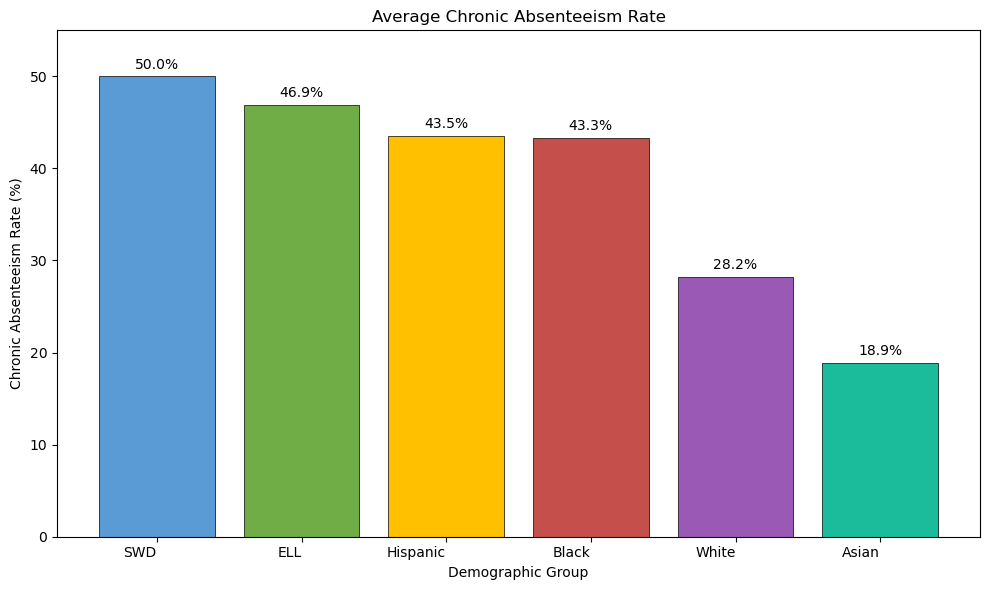

In [104]:
# Filter out demographics
category_df = edu_df[edu_df["Category"].isin(["Asian", "Black", "Hispanic", "White", "Multi-Racial", "SWD", "ELL", "Econ Disadv"])].copy()

# Group by Category and calculate mean chronic absenteeism rate
grouped_df = category_df.groupby('Category')['% Chronically Absent'].mean().reset_index()
grouped_df = grouped_df.sort_values('% Chronically Absent', ascending=False)

print("Average Chronic Absenteeism by Demographic:")
print(grouped_df)

# Create a bar chart with different colors for each demographic
plt.figure(figsize=(10, 6))

# Simple distinct colors for each demographic group
colors = ['#5B9BD5', '#70AD47', '#FFC000', '#C5504B', '#9B59B6', '#1ABC9C', '#F39C12', '#E74C3C']

bars = plt.bar(grouped_df['Category'], grouped_df['% Chronically Absent'], 
               color=colors[:len(grouped_df)], edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.title('Average Chronic Absenteeism Rate')
plt.xlabel('Demographic Group')
plt.ylabel('Chronic Absenteeism Rate (%)')
plt.xticks(rotation=0, ha='right')
plt.ylim(0, max(grouped_df['% Chronically Absent']) * 1.1)
plt.tight_layout()
plt.show()

Average Chronic Absenteeism by Demographic:
   Category  % Chronically Absent
4       SWD             49.986875
2       ELL             46.921875
3  Hispanic             43.518125
1     Black             43.308750
5     White             28.194375
0     Asian             18.896250


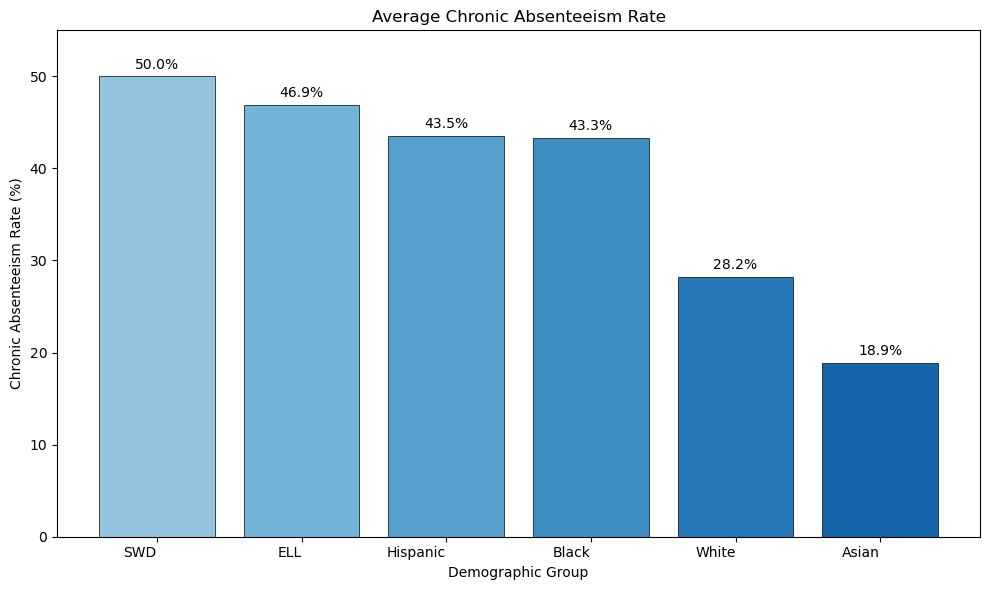

In [101]:
# Filter out demographics
category_df = edu_df[edu_df["Category"].isin(["Asian", "Black", "Hispanic", "White", "Multi-Racial", "SWD", "ELL", "Econ Disadv"])].copy()

# Group by Category and calculate mean chronic absenteeism rate
grouped_df = category_df.groupby('Category')['% Chronically Absent'].mean().reset_index()
grouped_df = grouped_df.sort_values('% Chronically Absent', ascending=False)

print("Average Chronic Absenteeism by Demographic:")
print(grouped_df)

# Create a gradient bar chart
plt.figure(figsize=(10, 6))

# Create a simple blue gradient
import matplotlib.cm as cm
colors = cm.Blues(np.linspace(0.4, 0.8, len(grouped_df)))

bars = plt.bar(grouped_df['Category'], grouped_df['% Chronically Absent'], 
               color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')

plt.title('Average Chronic Absenteeism Rate')
plt.xlabel('Demographic Group')
plt.ylabel('Chronic Absenteeism Rate (%)')
plt.xticks(rotation=0, ha='right')
plt.ylim(0, max(grouped_df['% Chronically Absent']) * 1.1)
plt.tight_layout()
plt.show()

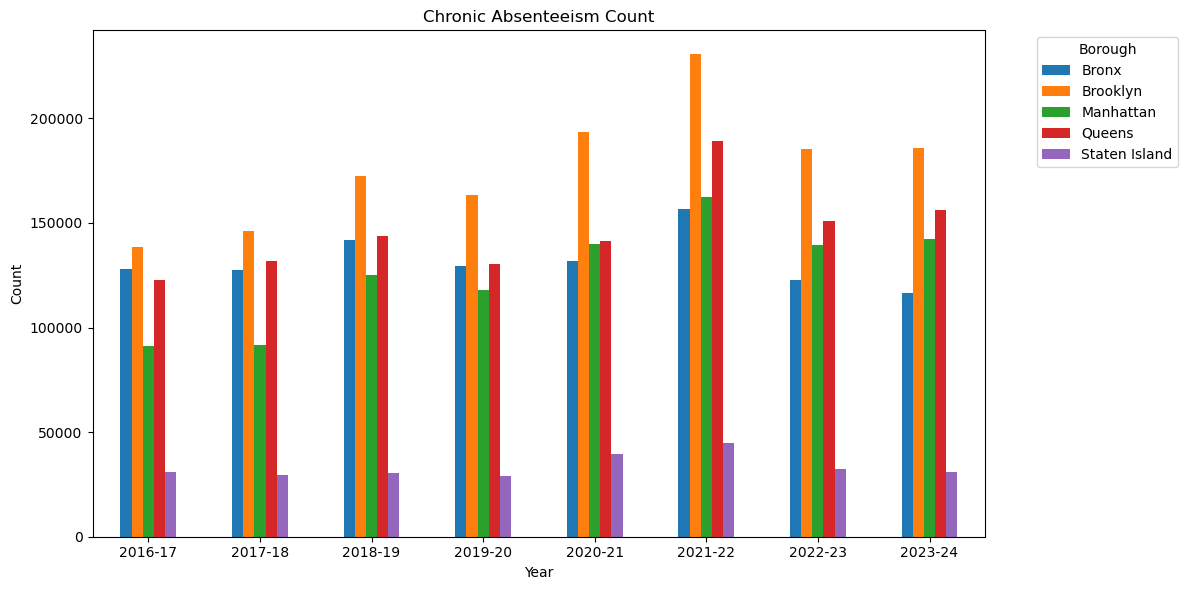

In [108]:
# Group and pivot
pivot = edu_df.groupby(['Year', 'Borough'])['# Chronically Absent'].sum().unstack().fillna(0)

# Plot stacked bar chart
pivot.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.title('Chronic Absenteeism Count')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

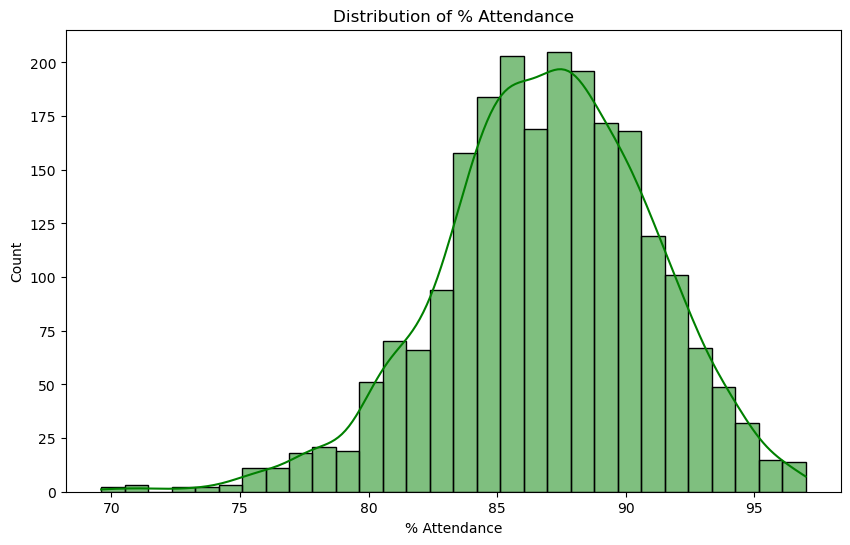

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(edu_df['% Attendance'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of % Attendance')
plt.xlabel('% Attendance')
plt.ylabel('Count')
plt.show()

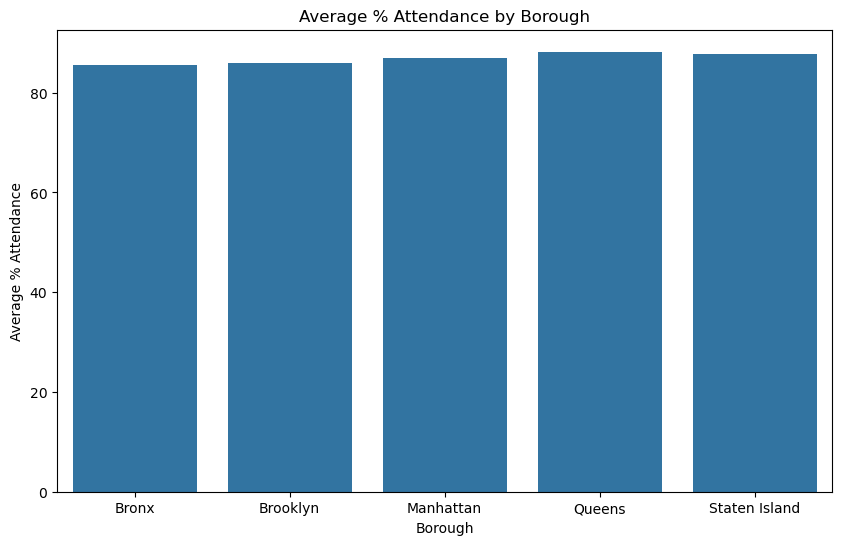

In [15]:
attendance_borough = edu_df.groupby('Borough')['% Attendance'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=attendance_borough, x='Borough', y='% Attendance')
plt.title('Average % Attendance by Borough')
plt.xlabel('Borough')
plt.ylabel('Average % Attendance')
plt.show()

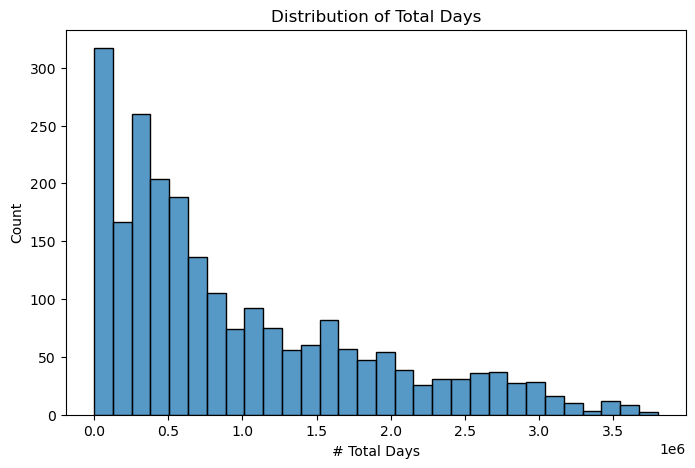

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=edu_df, x="# Total Days", bins=30, kde=False)
plt.title("Distribution of Total Days")
plt.xlabel("# Total Days")
plt.ylabel("Count")
plt.show()

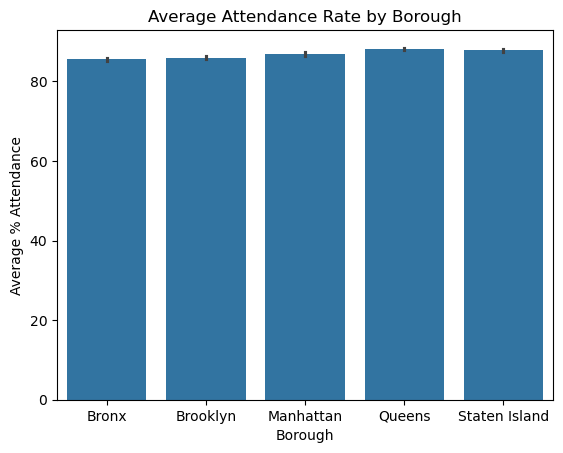

In [17]:
sns.barplot(data=edu_df, x='Borough', y='% Attendance', estimator='mean')
plt.title('Average Attendance Rate by Borough')
plt.ylabel('Average % Attendance')
plt.show()

In [18]:
# plt.figure(figsize=(10,6))
#sns.barplot(data=edu_df, x="Grade", y="% Attendance", errorbar=None, order=sorted(attendance["Grade"].unique()))
#plt.title("Average % Attendance by Grade")
#plt.xlabel("Grade")
#plt.ylabel("Average % Attendance")
#plt.show()

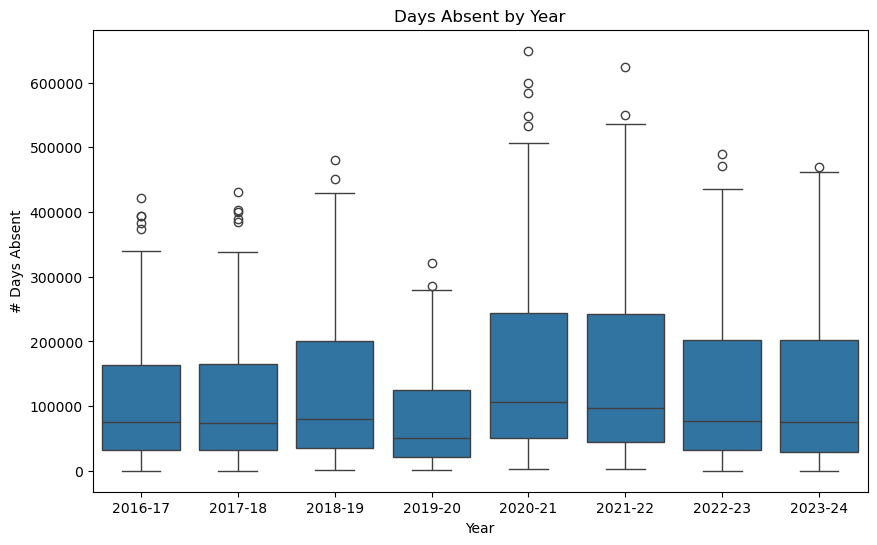

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=edu_df, x="Year", y="# Days Absent")
plt.title("Days Absent by Year")
plt.xlabel("Year")
plt.ylabel("# Days Absent")
plt.show()

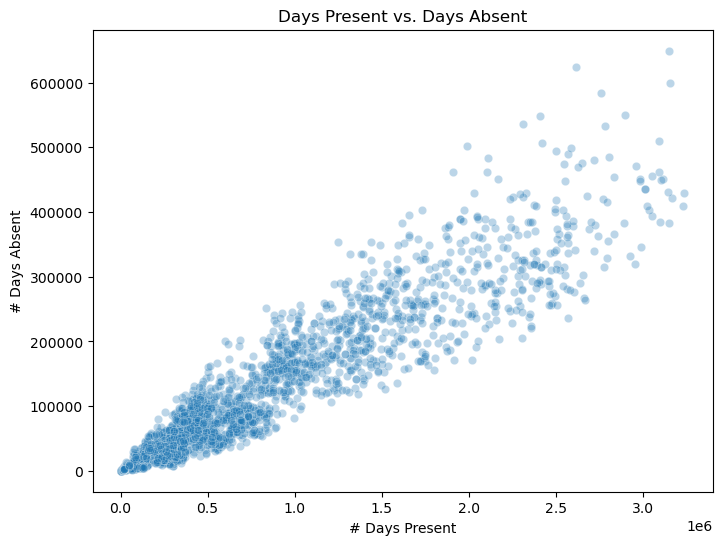

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=edu_df, x="# Days Present", y="# Days Absent", alpha=0.3)
plt.title("Days Present vs. Days Absent")
plt.xlabel("# Days Present")
plt.ylabel("# Days Absent")
plt.show()

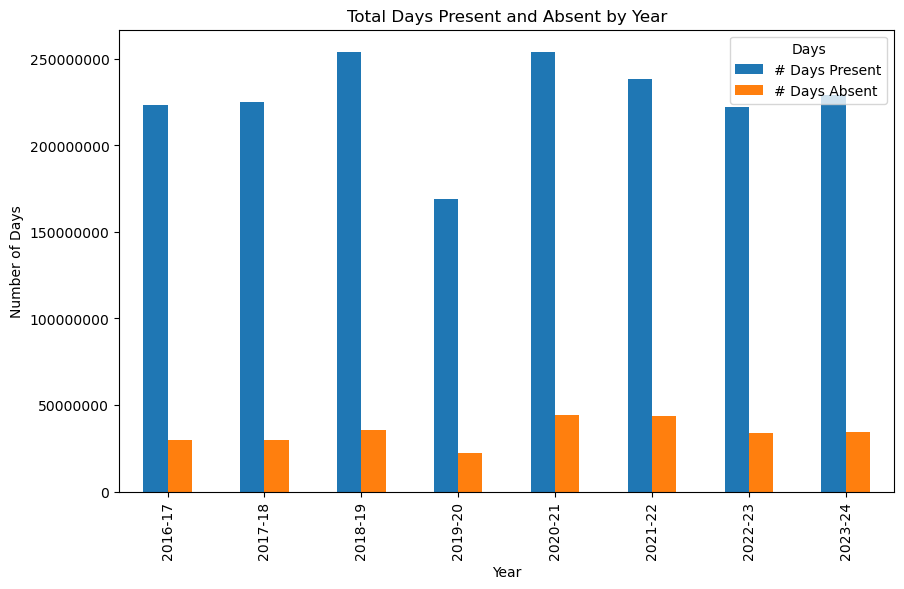

In [21]:
import matplotlib.ticker as mtick
agg_df = edu_df.groupby("Year")[["# Total Days", "# Days Absent", "# Days Present"]].sum()
ax = agg_df[["# Days Present", "# Days Absent"]].plot(kind="bar", stacked=False, figsize=(10,6))

# disable scientific notation on y-axis
ax.yaxis.get_major_formatter().set_scientific(False)

plt.title("Total Days Present and Absent by Year")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.legend(title="Days")
plt.show()

In [22]:
edu_df['Grade'].value_counts()

Grade
9     570
10    570
11    570
12    570
Name: count, dtype: Int64

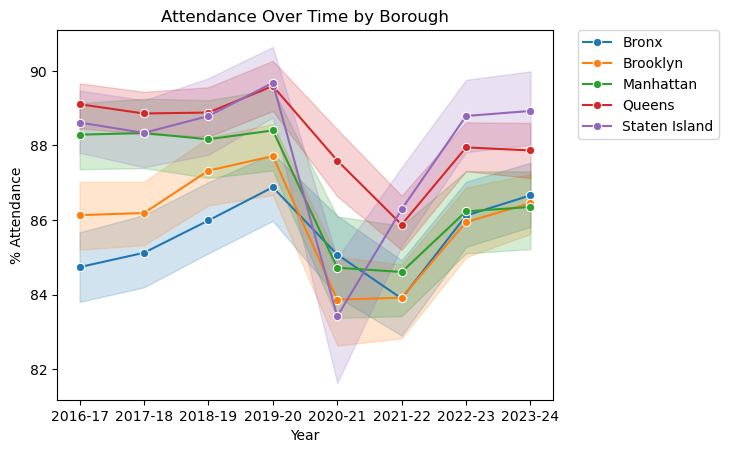

In [23]:
edu_df['Year'] = edu_df['Year'].astype(str)
sns.lineplot(data=edu_df, x='Year', y='% Attendance', hue='Borough', marker='o')
plt.title('Attendance Over Time by Borough')
plt.ylabel('% Attendance')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',borderaxespad=0)
plt.show()

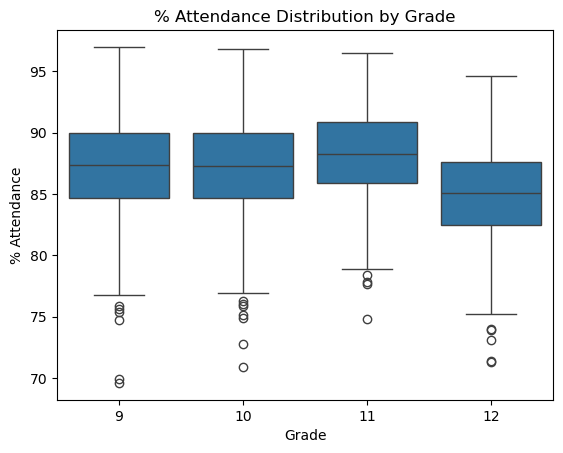

In [24]:
sns.boxplot(data=edu_df, x='Grade', y='% Attendance')
plt.title('% Attendance Distribution by Grade')
plt.show()

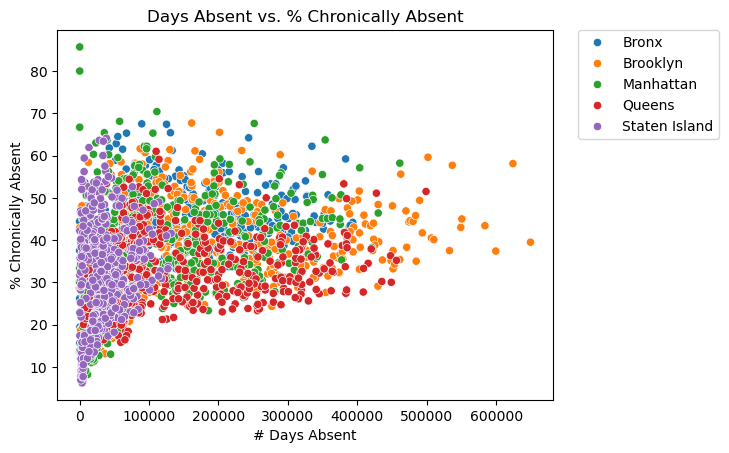

In [25]:
sns.scatterplot(data=edu_df, x='# Days Absent', y='% Chronically Absent', hue='Borough')
plt.title('Days Absent vs. % Chronically Absent')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',borderaxespad=0)
plt.show()

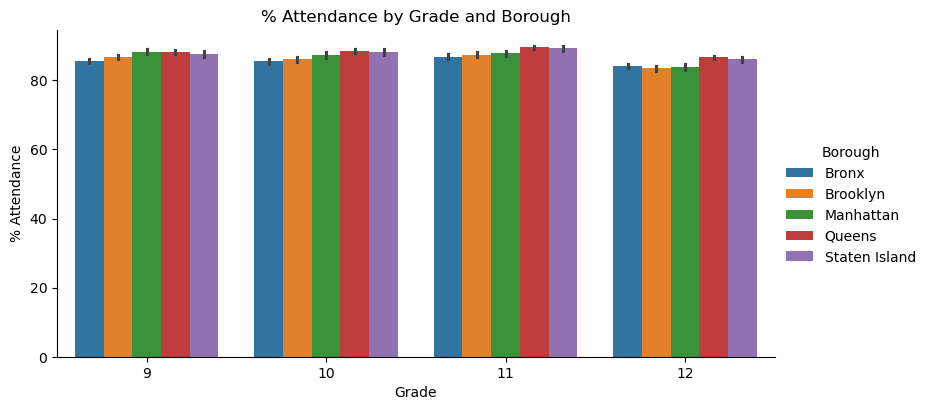

In [26]:
sns.catplot(data=edu_df, x='Grade', y='% Attendance', hue='Borough', kind='bar', height=4, aspect=2)
plt.title('% Attendance by Grade and Borough')
plt.show()

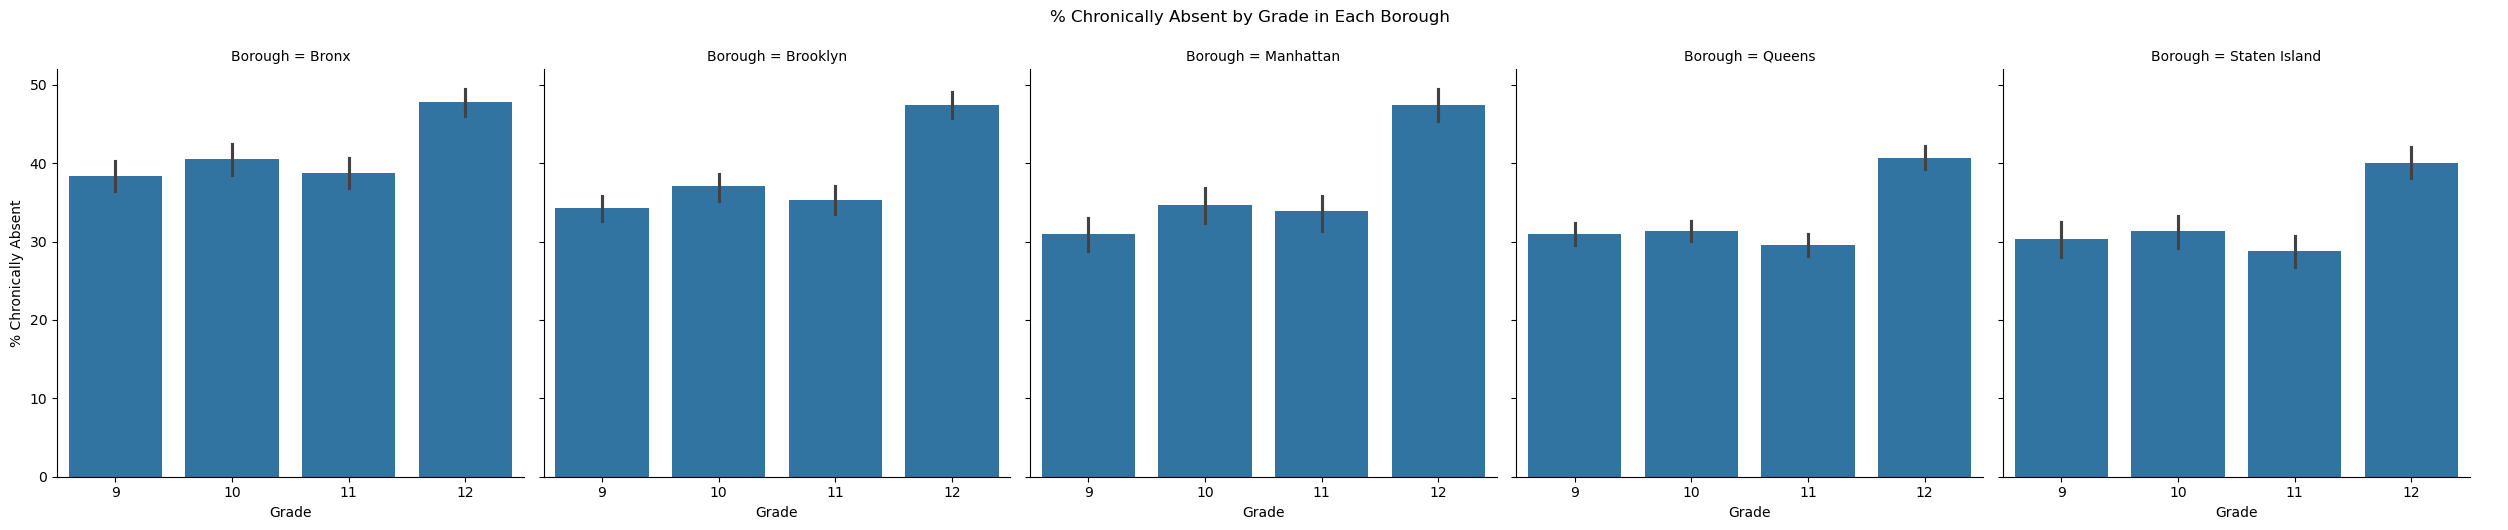

In [27]:
by_borough = sns.catplot(data=edu_df, x='Grade', y='% Chronically Absent', col='Borough', kind='bar')
by_borough.fig.suptitle('% Chronically Absent by Grade in Each Borough', y=1.05)
plt.show()

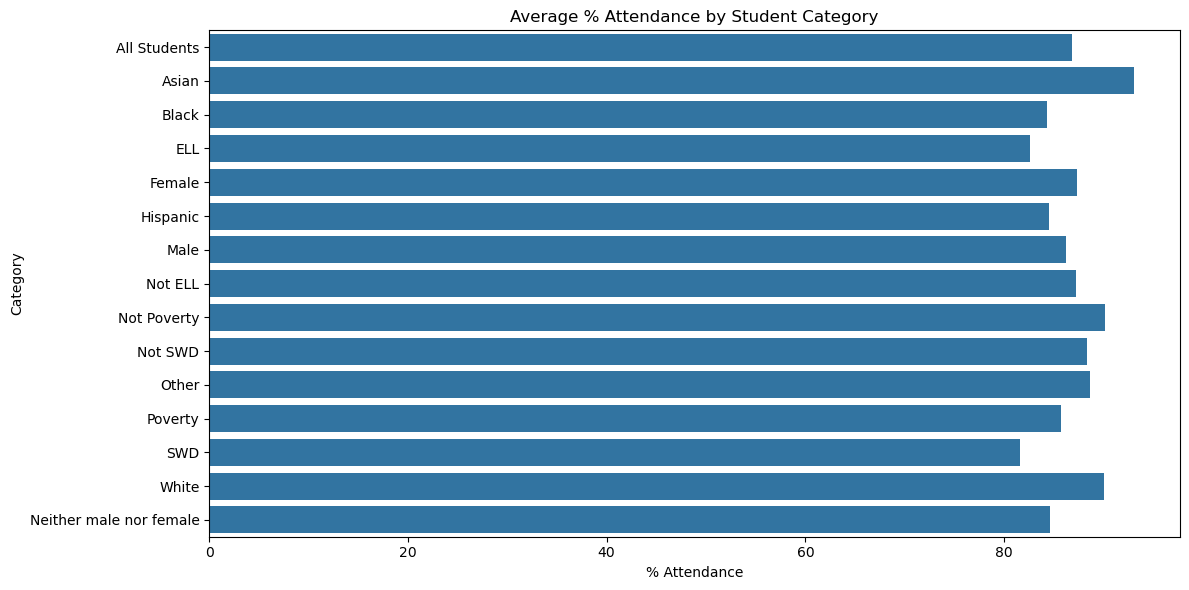

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=edu_df, x="% Attendance", y="Category", estimator="mean", errorbar=None, order=edu_df["Category"].unique())
plt.title("Average % Attendance by Student Category")
plt.xlabel("% Attendance")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

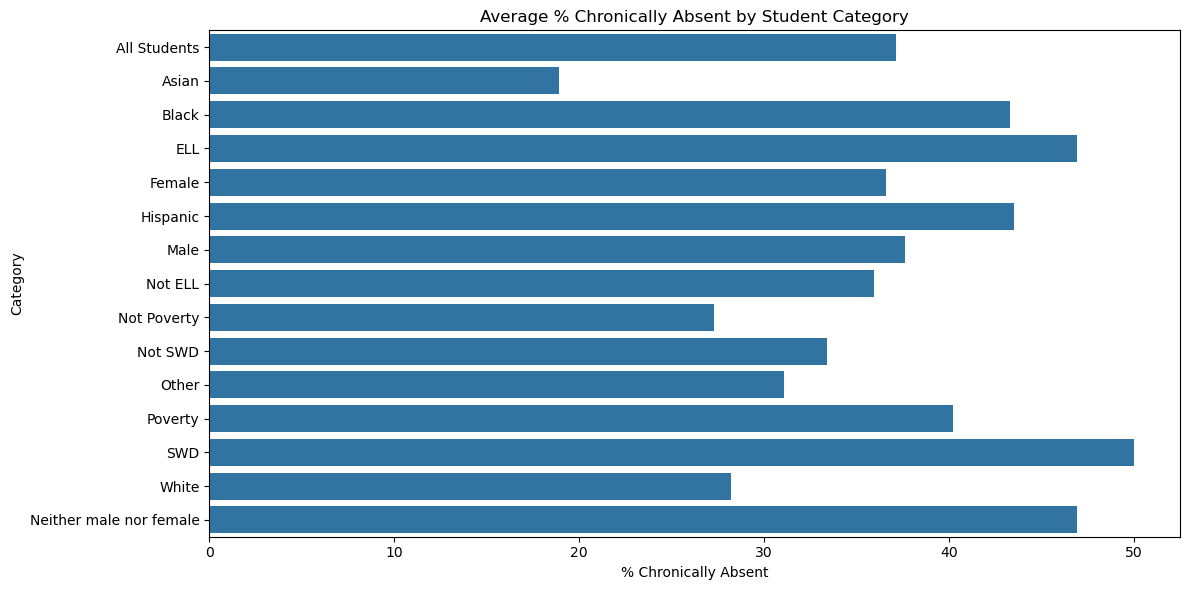

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(data=edu_df, x="% Chronically Absent", y="Category", estimator="mean", errorbar=None, order=edu_df["Category"].unique())
plt.title("Average % Chronically Absent by Student Category")
plt.xlabel("% Chronically Absent")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

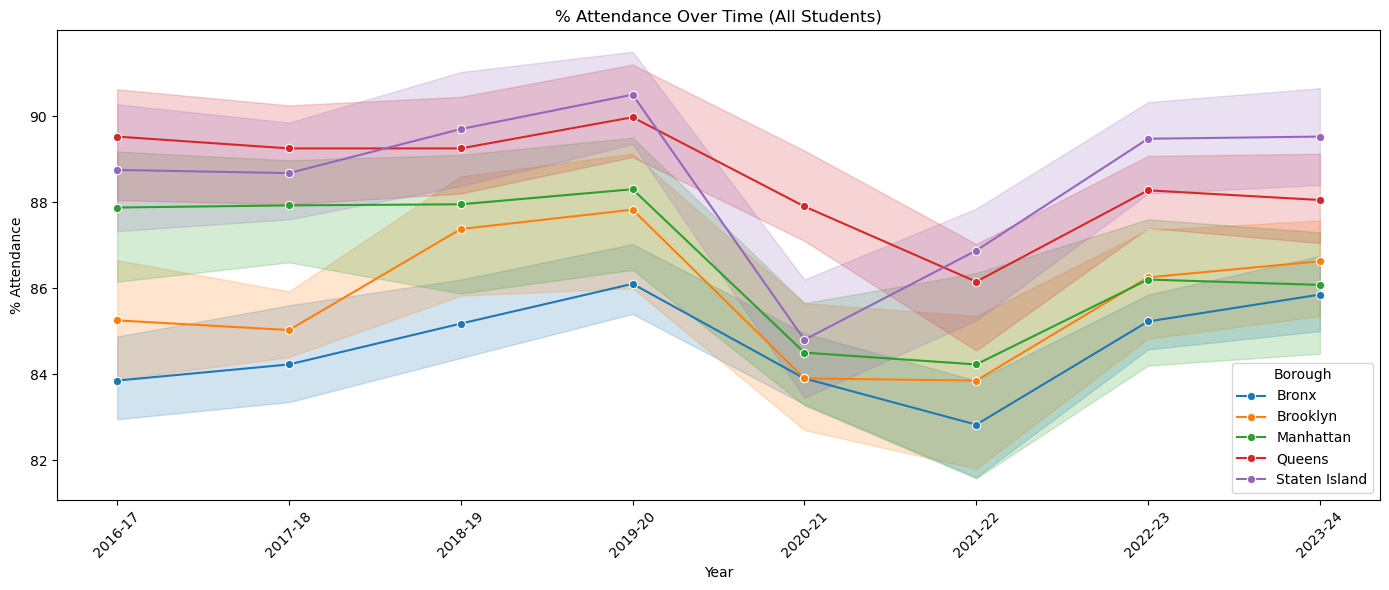

In [30]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=edu_df[edu_df["Category"] == "All Students"],
    x="Year", y="% Attendance", hue="Borough", marker="o"
)
plt.title("% Attendance Over Time (All Students)")
plt.xlabel("Year")
plt.ylabel("% Attendance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

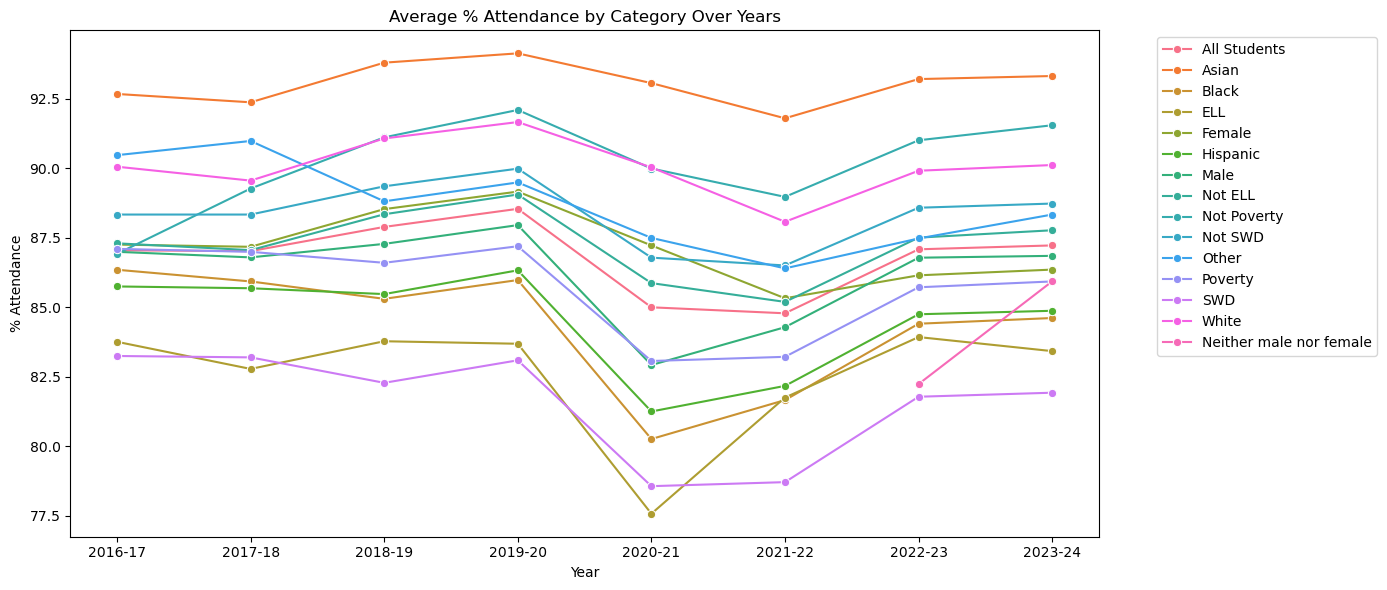

In [31]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=edu_df, x="Year", y="% Attendance", hue="Category", estimator="mean", errorbar=None, marker="o")
plt.title("Average % Attendance by Category Over Years")
plt.xlabel("Year")
plt.ylabel("% Attendance")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Regents

In [32]:
regents = pd.read_csv("/Users/sa10/Downloads/Education-Capstone/data/2014-15-to-2022-23-nyc-regents-overall-and-by-category---public 2 (1).csv", low_memory=False)

In [33]:
regents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372177 entries, 0 to 372176
Data columns (total 18 columns):
 #   Column                                         Non-Null Count   Dtype 
---  ------                                         --------------   ----- 
 0   School DBN                                     372177 non-null  object
 1   Borough                                        372177 non-null  object
 2   School Name                                    372177 non-null  object
 3   School Type                                    372177 non-null  object
 4   School Level                                   372177 non-null  object
 5   Regents Exam                                   372177 non-null  object
 6   Year                                           372177 non-null  object
 7   Category                                       372176 non-null  object
 8   Total Tested                                   372177 non-null  object
 9   Mean Score                                     3

In [34]:
# List of columns to convert to numeric
score_columns = [
    'Total Tested',
    'Mean Score',
    'Number Scoring Below 65',
    'Percent Scoring Below 65',
    'Number Scoring 65 or Above',
    'Percent Scoring 65 or Above',
    'Number Scoring 80 or Above',
    'Percent Scoring 80 or Above',
    'Number meeting CUNY proficiency requirmenets',
    'Percent meeting CUNY proficiency requirmenets'
]

# Replace 's' with NaN and convert columns
for col in score_columns:
    regents[col] = pd.to_numeric(regents[col].replace("s", pd.NA), errors='coerce')

# Convert Grade if present
if "Grade" in regents.columns:
    regents["Grade"] = pd.to_numeric(regents["Grade"], errors="coerce").astype("Int64")

regents

,School DBN,Borough,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number meeting CUNY proficiency requirmenets,Percent meeting CUNY proficiency requirmenets
0,01M292,Manhattan,Orchard Collegiate Academy,General Academic,High school,Algebra2/Trigonometry,2015,All Students,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01M292,Manhattan,Orchard Collegiate Academy,General Academic,High school,Chinese,2015,All Students,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01M292,Manhattan,Orchard Collegiate Academy,General Academic,High school,Common Core Algebra,2015,All Students,12.0,52.3,11.0,91.7,1.0,8.3,0.0,0.0,0.0,0.0
3,01M292,Manhattan,Orchard Collegiate Academy,General Academic,High school,Common Core English,2015,All Students,34.0,61.5,15.0,44.1,19.0,55.9,9.0,26.5,11.0,32.4
4,01M292,Manhattan,Orchard Collegiate Academy,General Academic,High school,Common Core Geometry,2015,All Students,10.0,49.2,9.0,90.0,1.0,10.0,0.0,0.0,1.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372172,84X640,Bronx,Family Life Academy Charter Schools High School,General Academic,High school,Common Core Algebra,2023,SWD,18.0,53.7,14.0,77.8,4.0,22.2,0.0,0.0,4.0,22.2
372173,84X640,Bronx,Family Life Academy Charter Schools High School,General Academic,High school,Common Core Algebra,2023,Non-SWD,74.0,64.0,28.0,37.8,46.0,62.2,2.0,2.7,32.0,43.2
372174,84X640,Bronx,Family Life Academy Charter Schools High School,General Academic,High school,Common Core Algebra2,2023,Non-SWD,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
372175,84X640,Bronx,Family Life Academy Charter Schools High School,General Academic,High school,Living Environment,2023,SWD,18.0,65.8,7.0,38.9,11.0,61.1,0.0,0.0,NaN,NaN


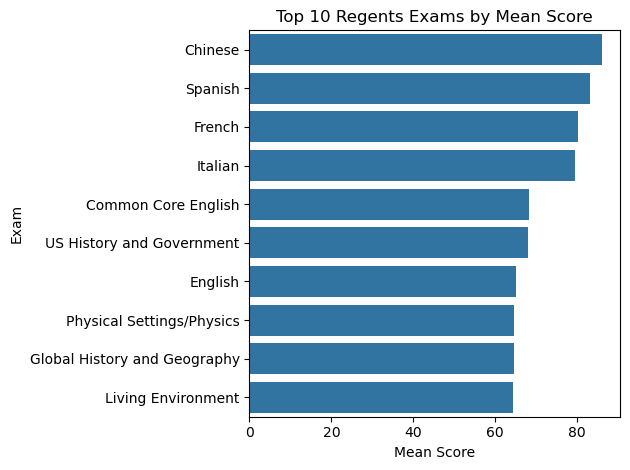

In [35]:
# group and average
mean_scores = regents.groupby('Regents Exam')['Mean Score'].mean().sort_values(ascending=False)

# plot top 10 exams by mean score
sns.barplot(x=mean_scores.head(10), y=mean_scores.head(10).index)
plt.title('Top 10 Regents Exams by Mean Score')
plt.xlabel('Mean Score')
plt.ylabel('Exam')
plt.tight_layout()
plt.show()

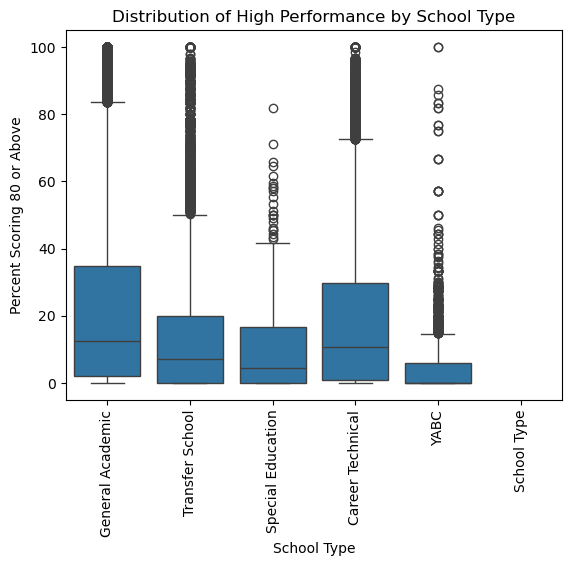

In [36]:
sns.boxplot(data=regents, x='School Type', y='Percent Scoring 80 or Above')
plt.title('Distribution of High Performance by School Type')
plt.xticks(rotation=90)
plt.show()

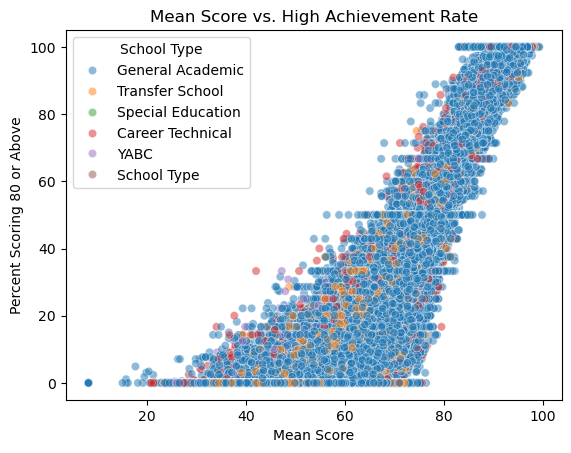

In [37]:
sns.scatterplot(data=regents, x='Mean Score', y='Percent Scoring 80 or Above', hue='School Type', alpha=0.5)
plt.title('Mean Score vs. High Achievement Rate')
plt.show()

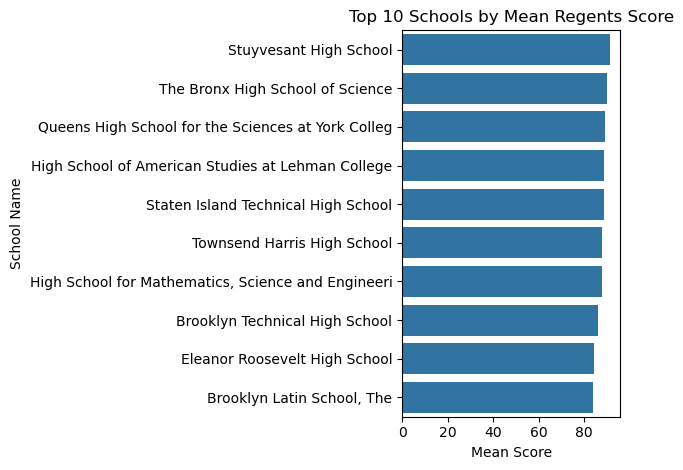

In [38]:
top_schools = (regents.groupby('School Name')['Mean Score'].mean().sort_values(ascending=False).head(10))
sns.barplot(x=top_schools.values, y=top_schools.index)
plt.title('Top 10 Schools by Mean Regents Score')
plt.xlabel('Mean Score')
plt.ylabel('School Name')
plt.tight_layout()
plt.show()

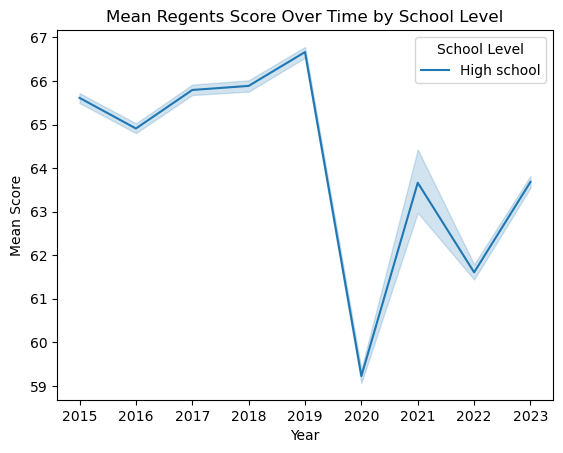

In [39]:
# drop nulls and make a copy safely
df_filtered = regents.dropna(subset=['Year', 'Mean Score']).copy()

# convert Year to integer
df_filtered['Year'] = df_filtered['Year'].astype(int)
sns.lineplot(data=df_filtered, x='Year', y='Mean Score', hue='School Level', estimator='mean')
plt.title('Mean Regents Score Over Time by School Level')
plt.ylabel('Mean Score')
plt.show()

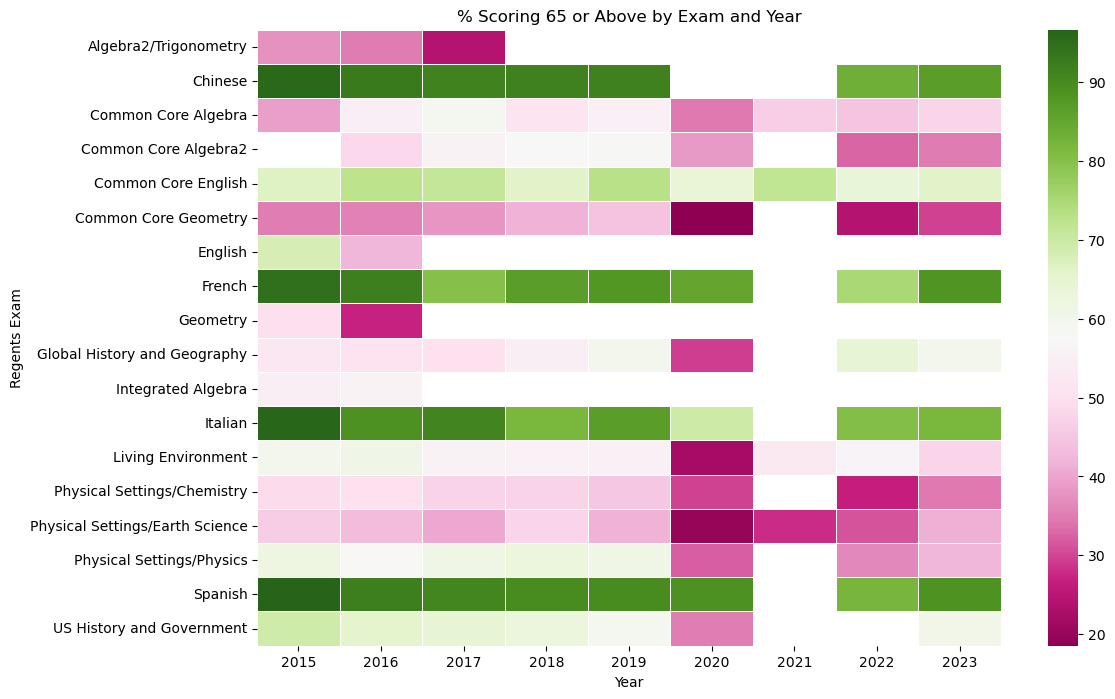

In [40]:
# pivot table for heatmap
pivot = regents.pivot_table(index='Regents Exam', columns='Year', values='Percent Scoring 65 or Above', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='PiYG', annot=False, linewidths=0.5)
plt.title('% Scoring 65 or Above by Exam and Year')
plt.xlabel('Year')
plt.ylabel('Regents Exam')
plt.show()

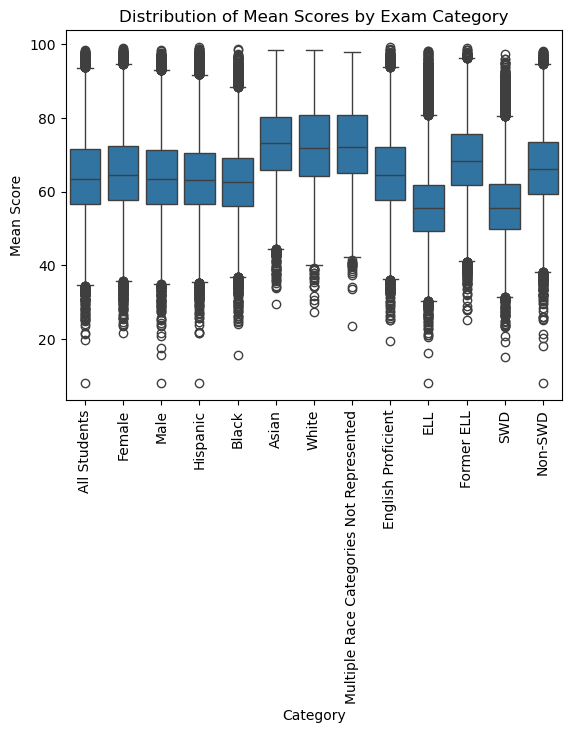

In [41]:
df_box = regents.dropna(subset=['Mean Score'])

sns.boxplot(data=df_box, x='Category', y='Mean Score')
plt.title('Distribution of Mean Scores by Exam Category')
plt.xticks(rotation=90)
plt.show()

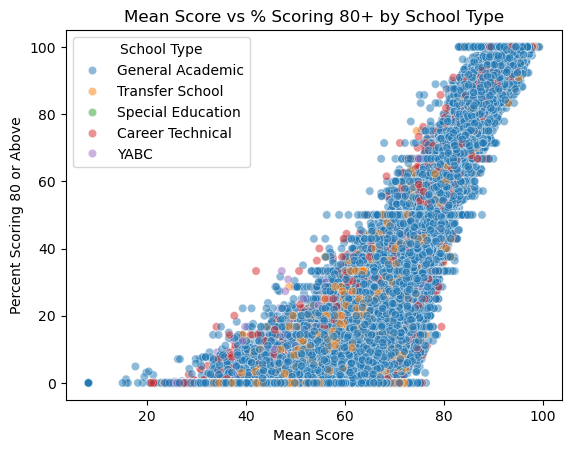

In [42]:
df_scatter = regents.dropna(subset=['Mean Score', 'Percent Scoring 80 or Above'])

sns.scatterplot(data=df_scatter, x='Mean Score', y='Percent Scoring 80 or Above', hue='School Type', alpha=0.5)
plt.title('Mean Score vs % Scoring 80+ by School Type')
plt.show()

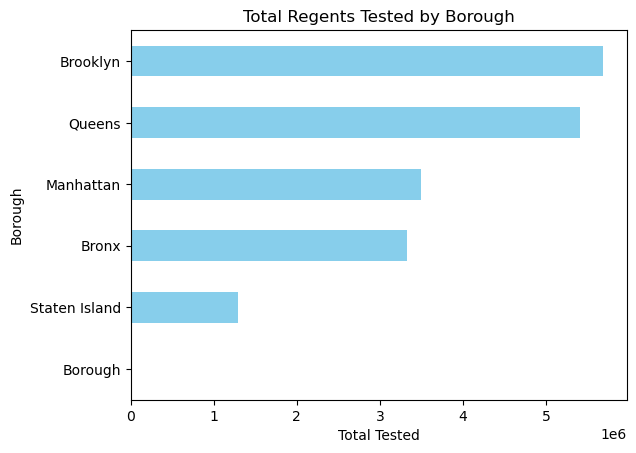

In [43]:
# Sum total tested by borough
borough_tested = regents.groupby('Borough')['Total Tested'].sum().sort_values()

# Plot
borough_tested.plot(kind='barh', title='Total Regents Tested by Borough', color='skyblue')
plt.xlabel('Total Tested')
plt.show()

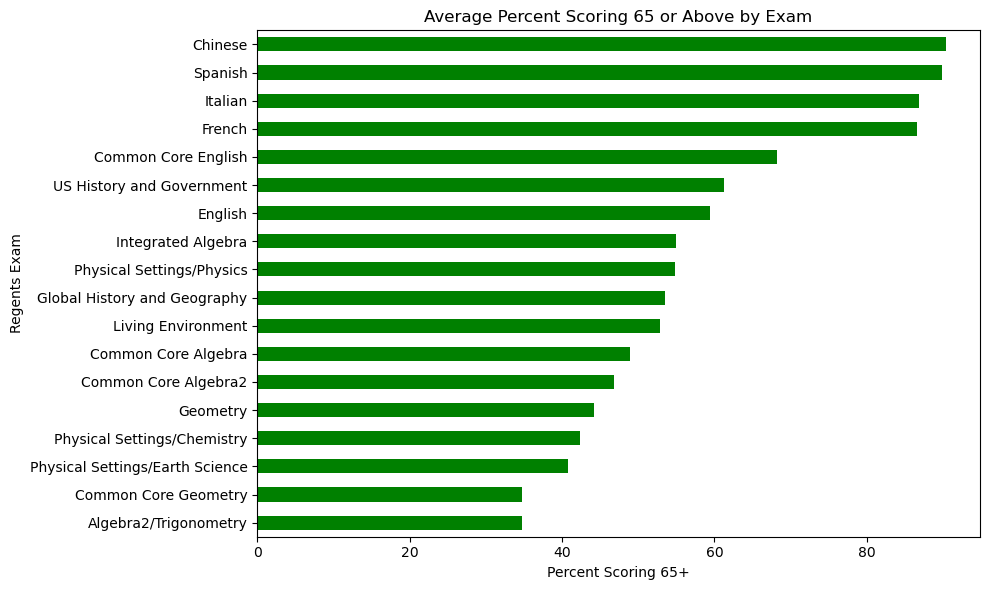

In [44]:
exam_perf = regents.dropna(subset=['Percent Scoring 65 or Above'])

# Average performance by exam
exam_scores = exam_perf.groupby('Regents Exam')['Percent Scoring 65 or Above'].mean().sort_values()

# Plot
plt.figure(figsize=(10, 6))
exam_scores.plot(kind='barh', title='Average Percent Scoring 65 or Above by Exam', color='green')
plt.xlabel('Percent Scoring 65+')
plt.tight_layout()
plt.show()

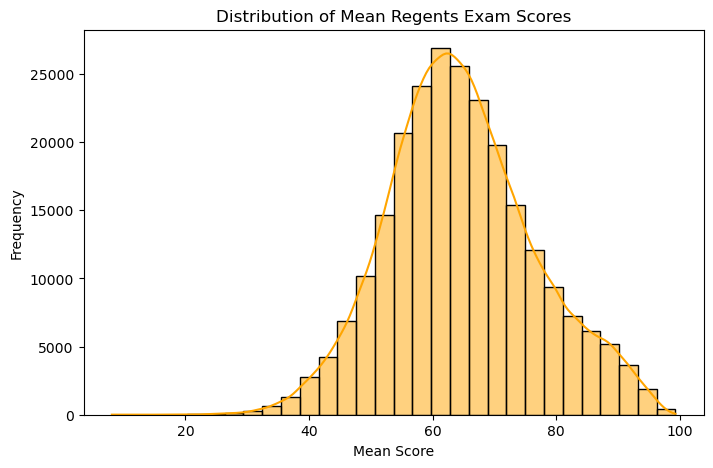

In [45]:
# Drop missing values
mean_scores = regents['Mean Score'].dropna()

# Plot
plt.figure(figsize=(8,5))
sns.histplot(mean_scores, bins=30, kde=True, color='orange')
plt.title('Distribution of Mean Regents Exam Scores')
plt.xlabel('Mean Score')
plt.ylabel('Frequency')
plt.show()

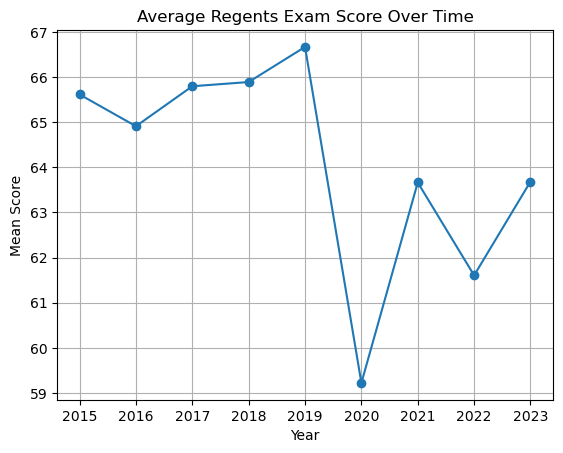

In [46]:
# Group and average
score_by_year = regents.dropna(subset=['Mean Score'])

avg_scores = score_by_year.groupby('Year')['Mean Score'].mean()

# Plot
avg_scores.plot(kind='line', marker='o', title='Average Regents Exam Score Over Time')
plt.ylabel('Mean Score')
plt.xlabel('Year')
plt.grid(True)
plt.show()

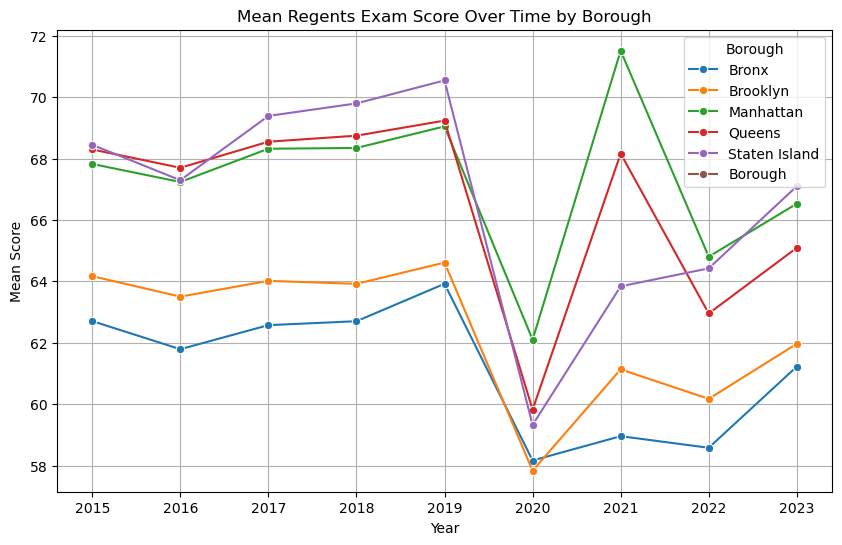

In [47]:
plt.figure(figsize=(10, 6))
# Group by year and borough
grouped = regents.groupby(['Year', 'Borough'])['Mean Score'].mean().reset_index()

sns.lineplot(data=grouped, x='Year', y='Mean Score', hue='Borough', marker='o')
plt.title('Mean Regents Exam Score Over Time by Borough')
plt.grid(True)
plt.show()

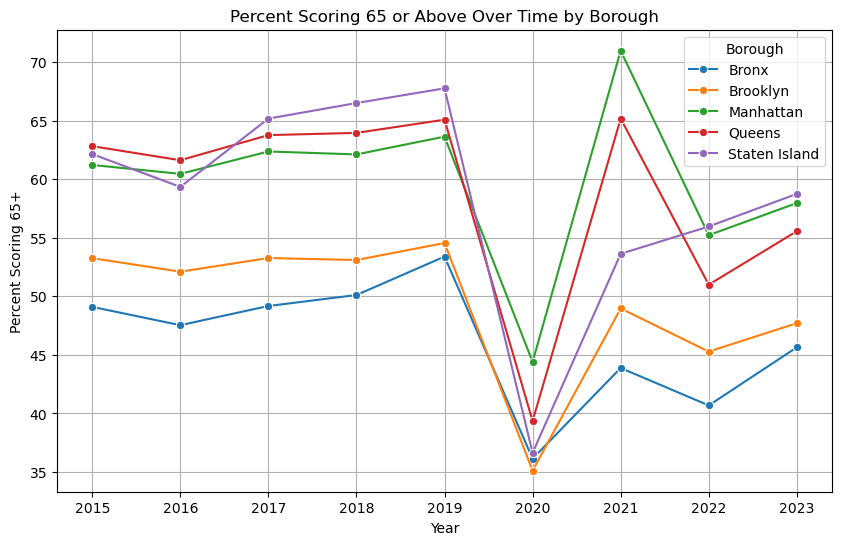

In [48]:
df_65 = regents.dropna(subset=['Percent Scoring 65 or Above']).copy()
df_65['Year'] = df_65['Year'].astype(str).str.extract(r'(\d{4})').astype(float)
# Group and plot
grouped_65 = df_65.groupby(['Year', 'Borough'])['Percent Scoring 65 or Above'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_65, x='Year', y='Percent Scoring 65 or Above', hue='Borough', marker='o')
plt.title('Percent Scoring 65 or Above Over Time by Borough')
plt.ylabel('Percent Scoring 65+')
plt.grid(True)
plt.show()

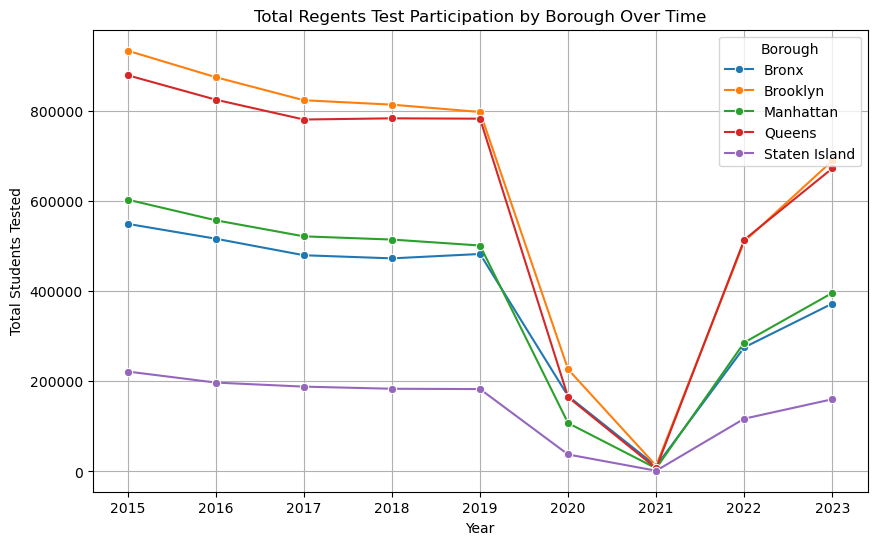

In [49]:
df_tested = regents.dropna(subset=['Total Tested']).copy()
df_tested['Year'] = df_tested['Year'].astype(str).str.extract(r'(\d{4})').astype(float)

grouped_tested = df_tested.groupby(['Year', 'Borough'])['Total Tested'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_tested, x='Year', y='Total Tested', hue='Borough', marker='o')
plt.title('Total Regents Test Participation by Borough Over Time')
plt.ylabel('Total Students Tested')
plt.grid(True)
plt.show()

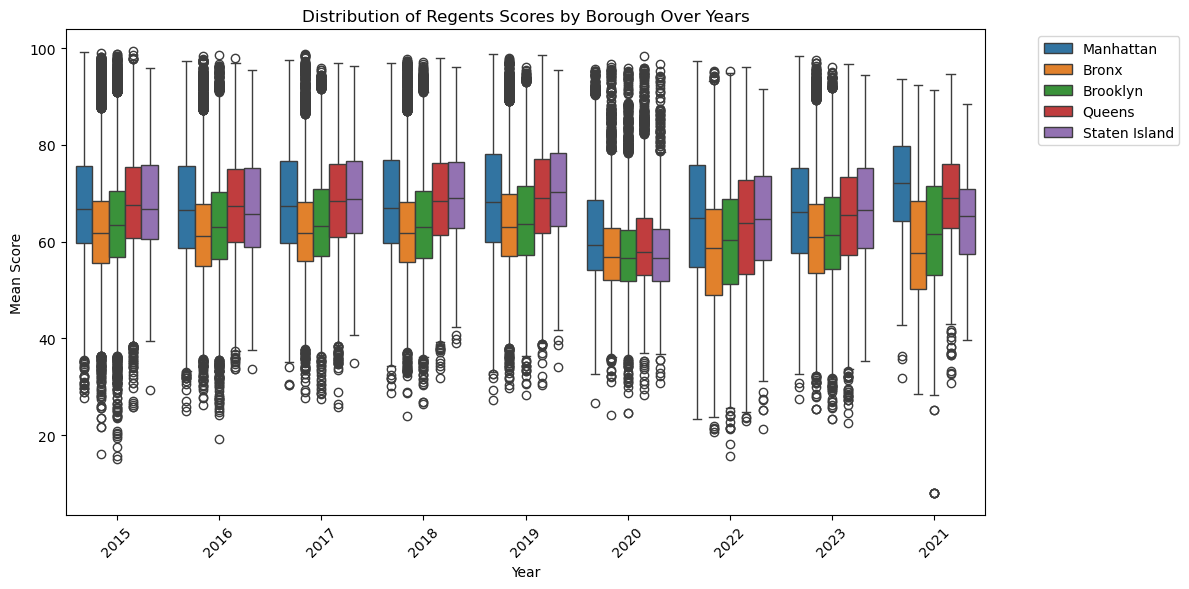

In [50]:
df_box = regents.dropna(subset=['Mean Score']).copy()
df_box['Year'] = df_box['Year'].astype(str).str.extract(r'(\d{4})')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_box, x='Year', y='Mean Score', hue='Borough')
plt.title('Distribution of Regents Scores by Borough Over Years')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

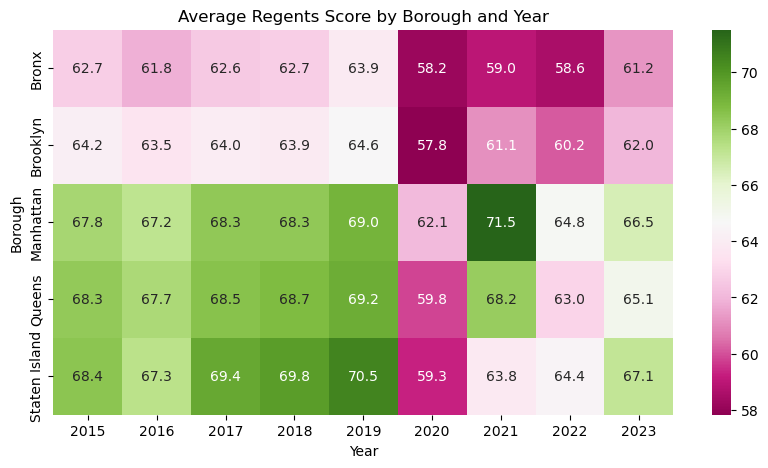

In [51]:
heatmap_data = regents.dropna(subset=['Mean Score']).copy()
heatmap_data['Year'] = heatmap_data['Year'].astype(str).str.extract(r'(\d{4})')

pivot = heatmap_data.pivot_table(index='Borough', columns='Year', values='Mean Score', aggfunc='mean')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='PiYG')
plt.title('Average Regents Score by Borough and Year')
plt.ylabel('Borough')
plt.xlabel('Year')
plt.show()

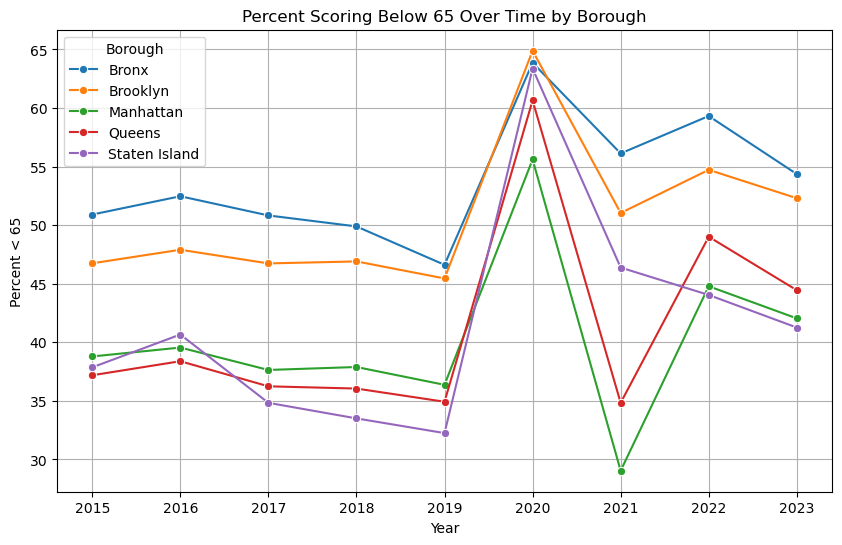

In [52]:
df_below65 = regents.dropna(subset=['Percent Scoring Below 65']).copy()
df_below65['Year'] = df_below65['Year'].astype(str).str.extract(r'(\d{4})').astype(float)

grouped_below65 = df_below65.groupby(['Year', 'Borough'])['Percent Scoring Below 65'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_below65, x='Year', y='Percent Scoring Below 65', hue='Borough', marker='o')
plt.title('Percent Scoring Below 65 Over Time by Borough')
plt.ylabel('Percent < 65')
plt.grid(True)
plt.show()

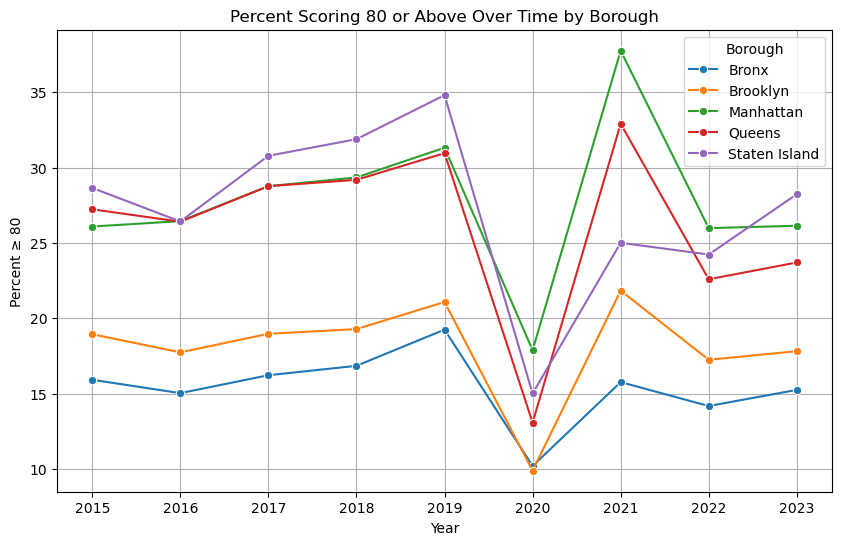

In [53]:
df_80 = regents.dropna(subset=['Percent Scoring 80 or Above']).copy()
df_80['Year'] = df_80['Year'].astype(str).str.extract(r'(\d{4})').astype(float)

grouped_80 = df_80.groupby(['Year', 'Borough'])['Percent Scoring 80 or Above'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_80, x='Year', y='Percent Scoring 80 or Above', hue='Borough', marker='o')
plt.title('Percent Scoring 80 or Above Over Time by Borough')
plt.ylabel('Percent ≥ 80')
plt.grid(True)
plt.show()

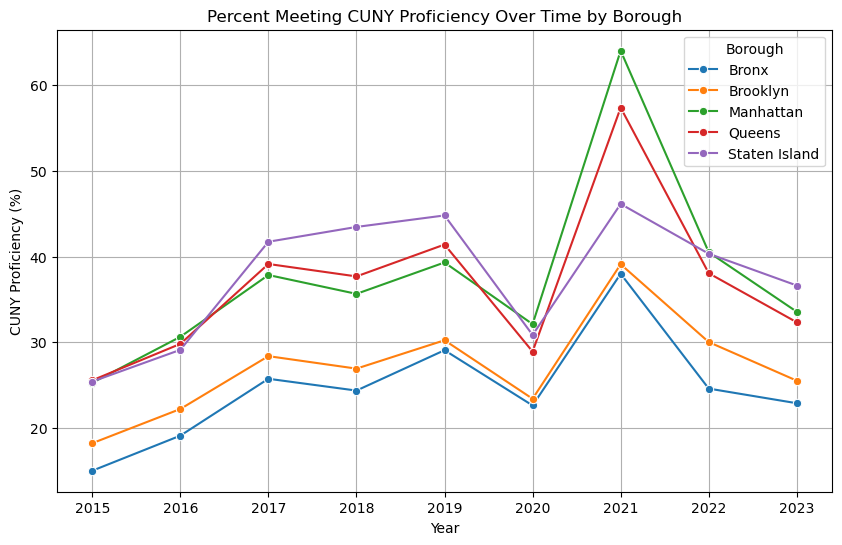

In [54]:
df_cuny = regents.dropna(subset=['Percent meeting CUNY proficiency requirmenets']).copy()
df_cuny['Year'] = df_cuny['Year'].astype(str).str.extract(r'(\d{4})').astype(float)

grouped_cuny = df_cuny.groupby(['Year', 'Borough'])['Percent meeting CUNY proficiency requirmenets'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_cuny, x='Year', y='Percent meeting CUNY proficiency requirmenets', hue='Borough', marker='o')
plt.title('Percent Meeting CUNY Proficiency Over Time by Borough')
plt.ylabel('CUNY Proficiency (%)')
plt.grid(True)
plt.show()

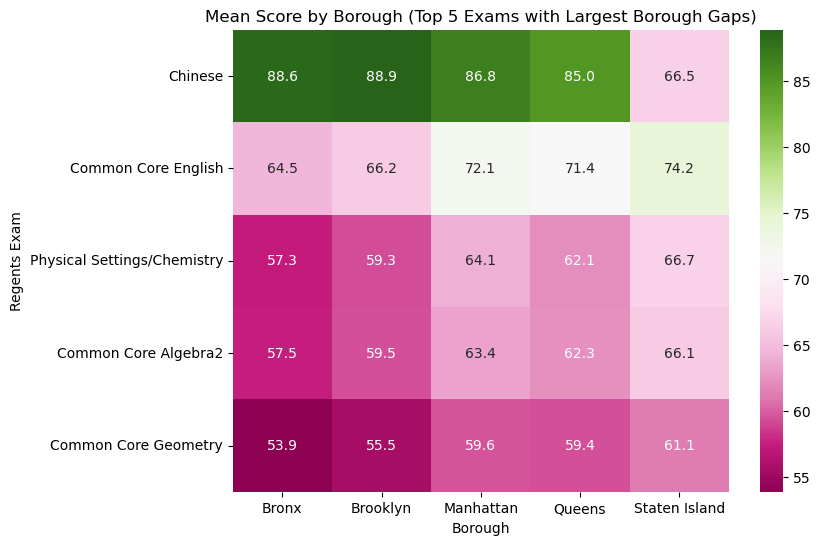

In [55]:
df_exam = regents.dropna(subset=['Mean Score']).copy()
df_exam['Year'] = df_exam['Year'].astype(str).str.extract(r'(\d{4})')

# Get average score by borough and exam
pivot_exam = df_exam.groupby(['Regents Exam', 'Borough'])['Mean Score'].mean().unstack()

# Calculate borough score range (max - min) for each exam
pivot_exam['Score Range'] = pivot_exam.max(axis=1) - pivot_exam.min(axis=1)

# Select top 5 exams with widest gaps
top_gap_exams = pivot_exam.sort_values('Score Range', ascending=False).head(5).drop(columns='Score Range')

plt.figure(figsize=(8, 6))
sns.heatmap(top_gap_exams, annot=True, fmt=".1f", cmap='PiYG')
plt.title('Mean Score by Borough (Top 5 Exams with Largest Borough Gaps)')
plt.ylabel('Regents Exam')
plt.xlabel('Borough')
plt.show()

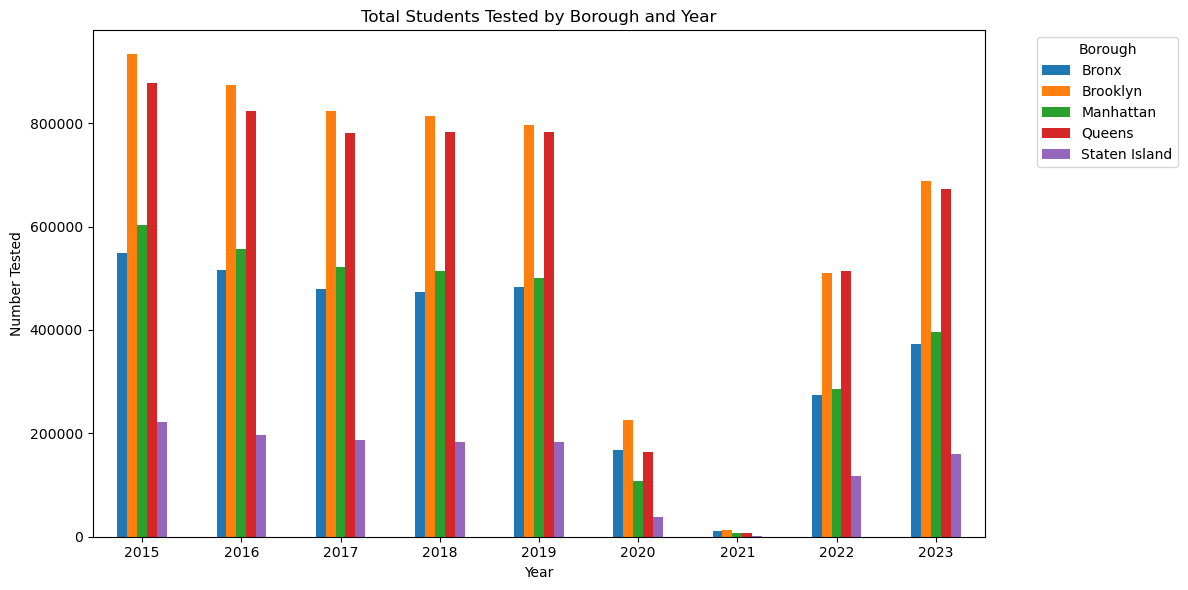

In [90]:
df_tested = regents.dropna(subset=['Total Tested']).copy()
df_tested['Year'] = df_tested['Year'].astype(str).str.extract(r'(\d{4})')

# Group and pivot
tested_pivot = df_tested.groupby(['Year', 'Borough'])['Total Tested'].sum().unstack().fillna(0)

# Plot stacked bar chart
tested_pivot.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.title('Total Students Tested by Borough and Year')
plt.ylabel('Number Tested')
plt.xticks(rotation=0)
plt.legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [57]:
regents['Year'] = regents['Year'].astype(str).str.extract(r'(\d{4})')
regents['Year'] = regents['Year'].astype(float)
regents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372177 entries, 0 to 372176
Data columns (total 18 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   School DBN                                     372177 non-null  object 
 1   Borough                                        372177 non-null  object 
 2   School Name                                    372177 non-null  object 
 3   School Type                                    372177 non-null  object 
 4   School Level                                   372177 non-null  object 
 5   Regents Exam                                   372177 non-null  object 
 6   Year                                           372173 non-null  float64
 7   Category                                       372176 non-null  object 
 8   Total Tested                                   372173 non-null  float64
 9   Mean Score                           

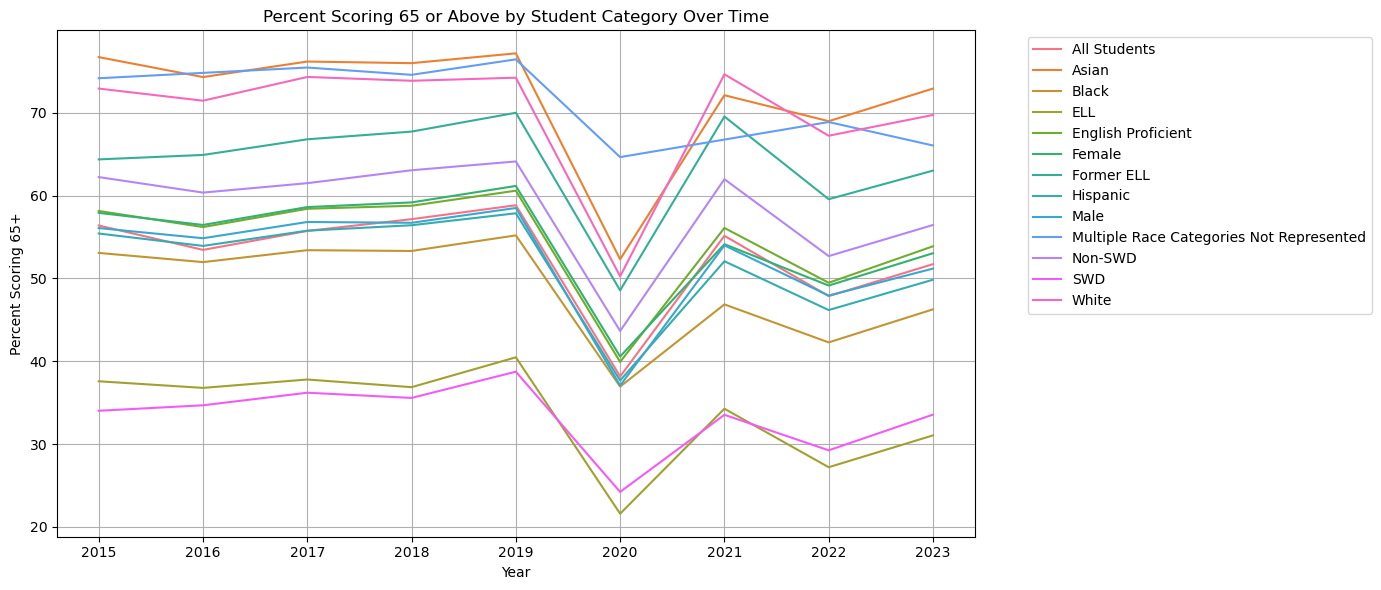

In [58]:
df_cat = regents.dropna(subset=['Percent Scoring 65 or Above', 'Category']).copy()

# Group by Year and Category
grouped_cat = df_cat.groupby(['Year', 'Category'])['Percent Scoring 65 or Above'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_cat, x='Year', y='Percent Scoring 65 or Above', hue='Category')
plt.title('Percent Scoring 65 or Above by Student Category Over Time')
plt.ylabel('Percent Scoring 65+')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


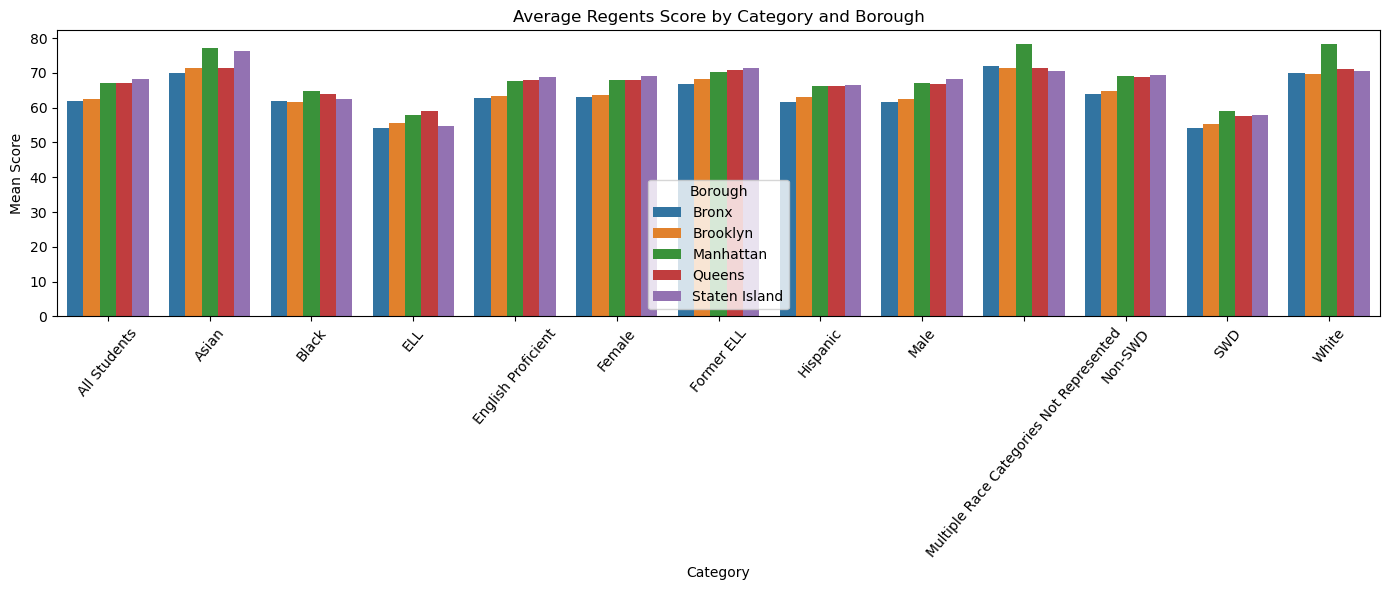

In [59]:
df_cat_boro = regents.dropna(subset=['Mean Score', 'Category']).copy()

# Group by Category and Borough
grouped_cb = df_cat_boro.groupby(['Borough', 'Category'])['Mean Score'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=grouped_cb, x='Category', y='Mean Score', hue='Borough')
plt.title('Average Regents Score by Category and Borough')
plt.ylabel('Mean Score')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

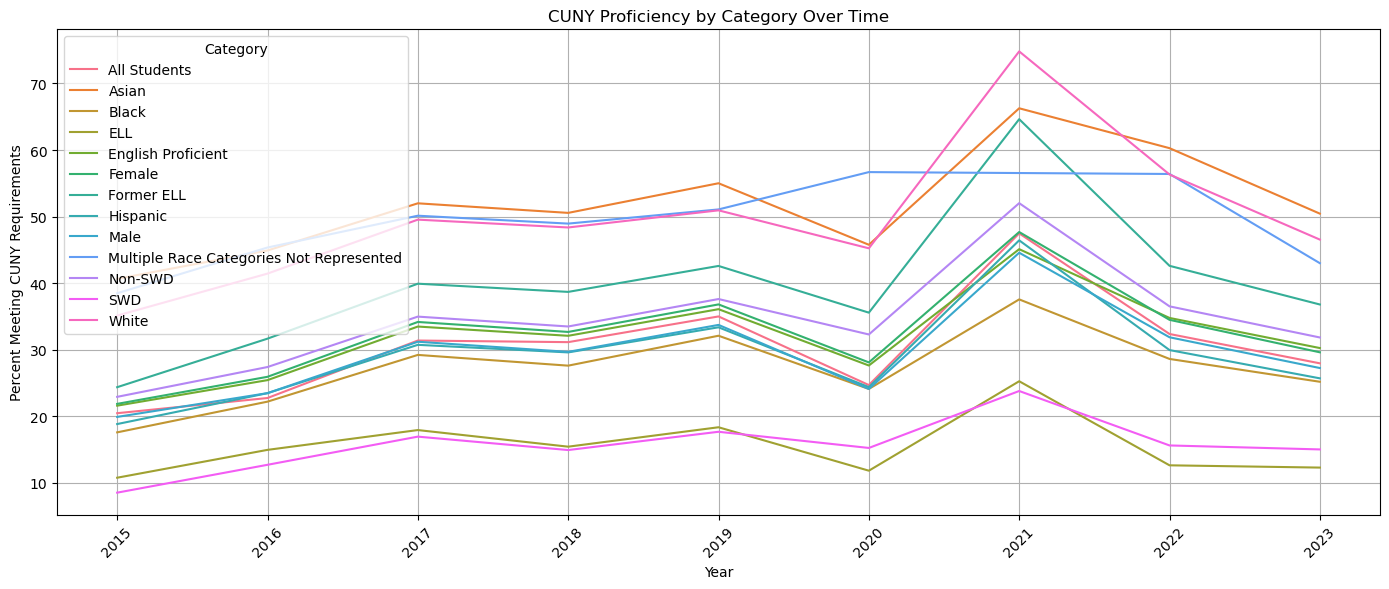

In [60]:
df_cuny_cat = regents.dropna(subset=['Percent meeting CUNY proficiency requirmenets', 'Category']).copy()

grouped_cuny_cat = df_cuny_cat.groupby(['Year', 'Category'])['Percent meeting CUNY proficiency requirmenets'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_cuny_cat, x='Year', y='Percent meeting CUNY proficiency requirmenets', hue='Category')
plt.title('CUNY Proficiency by Category Over Time')
plt.ylabel('Percent Meeting CUNY Requirements')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

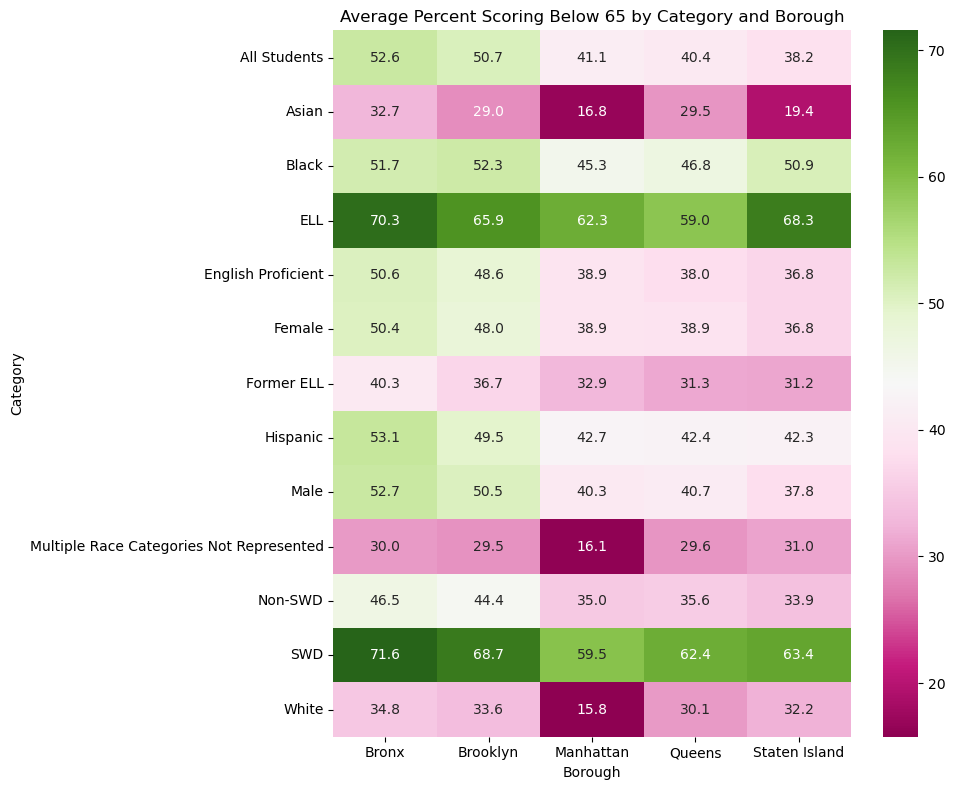

In [61]:
df_below_cat = regents.dropna(subset=['Percent Scoring Below 65', 'Category']).copy()

pivot_below = df_below_cat.groupby(['Category', 'Borough'])['Percent Scoring Below 65'].mean().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_below, annot=True, fmt=".1f", cmap='PiYG')
plt.title('Average Percent Scoring Below 65 by Category and Borough')
plt.ylabel('Category')
plt.xlabel('Borough')
plt.tight_layout()
plt.show()

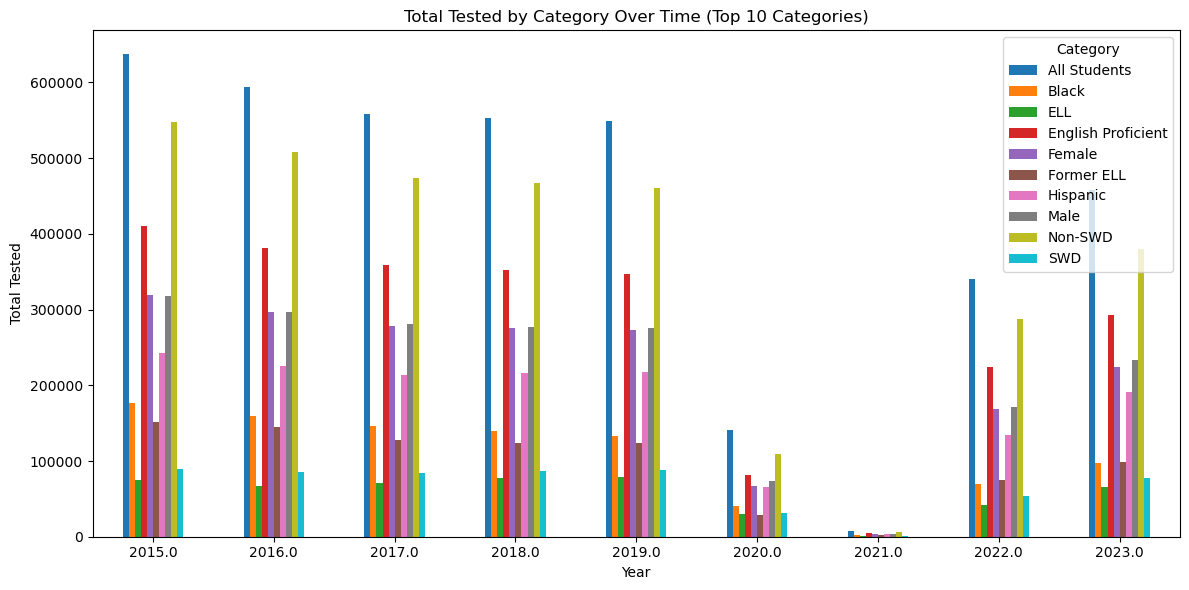

In [62]:
df_tested_cat = regents.dropna(subset=['Total Tested', 'Category']).copy()

# Limit to 10 most common categories
top_categories = df_tested_cat['Category'].value_counts().head(10).index
df_tested_top = df_tested_cat[df_tested_cat['Category'].isin(top_categories)]

grouped_tested = df_tested_top.groupby(['Year', 'Category'])['Total Tested'].sum().unstack().fillna(0)

grouped_tested.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.title('Total Tested by Category Over Time (Top 10 Categories)')
plt.ylabel('Total Tested')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Graduation

In [63]:
graduation = pd.read_csv("/Users/sa10/Downloads/Education-Capstone/data/2023-graduation-rates-public-borough.csv")

In [64]:
graduation.head()

,Borough,Category,Cohort Year,Cohort,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Cohort,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort
0,Bronx,All Students,2019,4 year August,12256,9733,79.4,9678,79.0,99.4,...,0.4,0.6,1381,11.3,957,7.8,74,0.6,91,0.7
1,Bronx,All Students,2018,4 year August,12487,9921,79.5,9874,79.1,99.5,...,0.4,0.5,1400,11.2,974,7.8,95,0.8,87,0.7
2,Bronx,All Students,2017,4 year August,13152,10220,77.7,10136,77.1,99.2,...,0.6,0.8,1761,13.4,1001,7.6,54,0.4,98,0.7
3,Bronx,All Students,2016,4 year August,13421,9938,74.0,9733,72.5,97.9,...,1.5,2.1,1976,14.7,1271,9.5,60,0.4,175,1.3
4,Bronx,All Students,2015,4 year August,13891,9752,70.2,8446,60.8,86.6,...,9.4,13.4,2124,15.3,1759,12.7,80,0.6,175,1.3


Opened data wrangler. 2,899 rows x 27 columns. Will explore value counts for categorical variables. Will calculate graduation year using cohort and cohort and cohort year. Will focus strictly on graduation variables.

In [65]:
graduation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2899 entries, 0 to 2898
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Borough                               2899 non-null   object
 1   Category                              2899 non-null   object
 2   Cohort Year                           2899 non-null   object
 3   Cohort                                2899 non-null   object
 4   # Total Cohort                        2899 non-null   object
 5   # Grads                               2899 non-null   object
 6   % Grads                               2899 non-null   object
 7   # Total Regents                       2899 non-null   object
 8   % Total Regents of Cohort             2899 non-null   object
 9   % Total Regents of Grads              2899 non-null   object
 10  # Advanced Regents                    2899 non-null   object
 11  % Advanced Regents of Cohort  

In [66]:
graduation.describe()

,Borough,Category,Cohort Year,Cohort,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Cohort,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort
count,2899,2899,2899,2899,2899,2899,2899,2899,2899,2899,...,2899,2899,2899,2899,2899,2899,2899,2899,2899,2899
unique,6,18,9,6,1462,2286,550,2289,613,357,...,245,357,1183,350,1075,310,260,93,221,59
top,Bronx,All Students,2017,4 year August,17,s,s,s,s,100.0,...,0.3,0.0,7,5.0,9,5.2,0,0.0,0,0.8
freq,580,180,400,645,11,24,24,24,24,141,...,152,141,43,33,44,38,399,502,169,242


Most cohort data is centered on August 2017, with most 4-years long. There might be some supressed data. Will delete those rows. Most frequent drop out rate is 5.2%. Might rid some diploma columns due to low frequencies.

In [67]:
# Dropped suppressed data

rows_to_drop = graduation.isin(['s']).any(axis=1)
graduation = graduation[~rows_to_drop]
graduation.describe()

,Borough,Category,Cohort Year,Cohort,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Cohort,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort
count,2875,2875,2875,2875,2875,2875,2875,2875,2875,2875,...,2875,2875,2875,2875,2875,2875,2875,2875,2875,2875
unique,6,18,9,6,1453,2285,549,2288,612,356,...,244,356,1182,349,1074,309,259,92,220,58
top,Manhattan,All Students,2017,4 year August,17,61,88.6,23,84.8,100.0,...,0.3,0.0,7,3.4,9,5.2,0,0.0,0,0.8
freq,578,180,400,637,11,10,20,10,20,141,...,152,141,43,33,44,38,399,502,169,242


In [68]:
# Dropped "Category" rows
more_rows_to_drop = graduation.isin(['Category']).any(axis=1)
graduation = graduation[~more_rows_to_drop]
graduation.describe()

,Borough,Category,Cohort Year,Cohort,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Cohort,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort
count,2870,2870,2870,2870,2870,2870,2870,2870,2870,2870,...,2870,2870,2870,2870,2870,2870,2870,2870,2870,2870
unique,5,17,8,5,1452,2284,548,2287,611,355,...,243,355,1181,348,1073,308,258,91,219,57
top,Manhattan,All Students,2017,4 year August,17,61,76.5,23,84.8,100.0,...,0.3,0.0,7,3.4,9,5.2,0,0.0,0,0.8
freq,578,180,400,637,11,10,20,10,20,141,...,152,141,43,33,44,38,399,502,169,242


In [69]:
# Ensure 'Cohort Year' is an integer type.
graduation['Cohort Year'] = pd.to_numeric(graduation['Cohort Year'], errors='coerce').fillna(0).astype(int)

# Extract the number from the 'Cohort' string directly using vectorized operations.
extracted_years = pd.to_numeric(
    graduation['Cohort'].str.extract(r'(\d+)', expand=False),
    errors='coerce'
).fillna(0).astype(int)

# Add the 'Cohort Year' column (now guaranteed int) and the 'extracted_years' Series (guaranteed int)to create the new 'Graduation Year' column.
graduation['Graduation Year'] = graduation['Cohort Year'] + extracted_years
graduation

,Borough,Category,Cohort Year,Cohort,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort,Graduation Year
0,Bronx,All Students,2019,4 year August,12256,9733,79.4,9678,79.0,99.4,...,0.6,1381,11.3,957,7.8,74,0.6,91,0.7,2023
1,Bronx,All Students,2018,4 year August,12487,9921,79.5,9874,79.1,99.5,...,0.5,1400,11.2,974,7.8,95,0.8,87,0.7,2022
2,Bronx,All Students,2017,4 year August,13152,10220,77.7,10136,77.1,99.2,...,0.8,1761,13.4,1001,7.6,54,0.4,98,0.7,2021
3,Bronx,All Students,2016,4 year August,13421,9938,74.0,9733,72.5,97.9,...,2.1,1976,14.7,1271,9.5,60,0.4,175,1.3,2020
4,Bronx,All Students,2015,4 year August,13891,9752,70.2,8446,60.8,86.6,...,13.4,2124,15.3,1759,12.7,80,0.6,175,1.3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,Staten Island,Not Econ Disadv,2016,6 year June,1981,1871,94.4,1847,93.2,98.7,...,1.3,19,1.0,71,3.6,3,0.2,17,0.9,2022
2895,Staten Island,Not Econ Disadv,2015,6 year June,1870,1726,92.3,1559,83.4,90.3,...,9.7,41,2.2,77,4.1,3,0.2,23,1.2,2021
2896,Staten Island,Not Econ Disadv,2014,6 year June,2022,1816,89.8,1646,81.4,90.6,...,9.4,52,2.6,125,6.2,6,0.3,23,1.1,2020
2897,Staten Island,Not Econ Disadv,2013,6 year June,2236,1985,88.8,1810,80.9,91.2,...,8.8,56,2.5,150,6.7,11,0.5,34,1.5,2019


In [70]:
graduation['% Grads'] = pd.to_numeric(graduation['% Grads'], errors='coerce')

In [71]:
# Dropped "All Students" rows
more_rows_to_drop_students = graduation.isin(['All Students']).any(axis=1)
graduation = graduation[~more_rows_to_drop_students]
graduation.describe()

,Cohort Year,% Grads,Graduation Year
count,2690.000000,2690.000000,2690.000000
mean,2015.126022,78.270409,2019.849442
std,2.116914,13.644792,2.118998
min,2012.000000,14.500000,2016.000000
25%,2013.000000,73.200000,2018.000000
50%,2015.000000,81.600000,2020.000000
75%,2017.000000,87.800000,2022.000000
max,2019.000000,98.800000,2023.000000


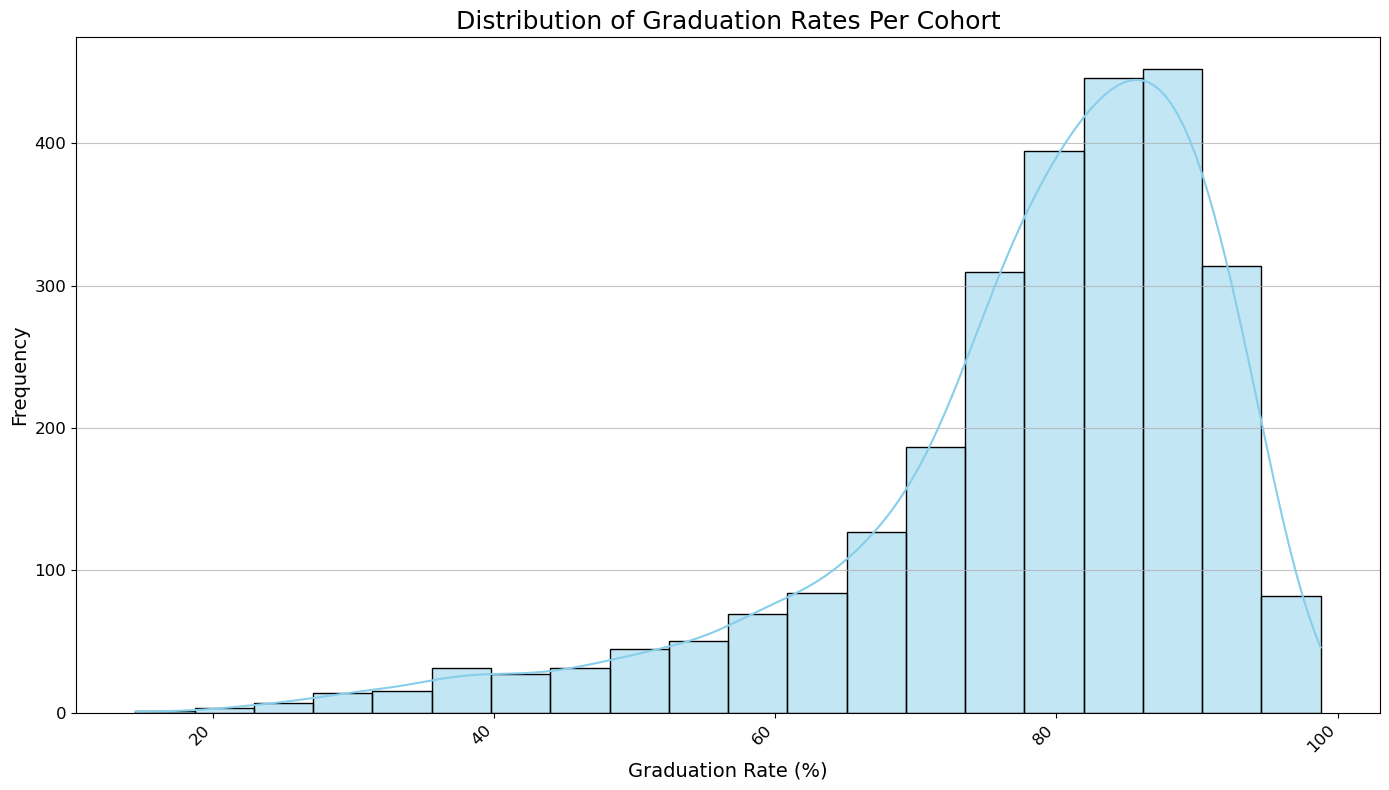

In [72]:
# Distribution of % Grads
plt.figure(figsize=(14, 8))
sns.histplot(graduation['% Grads'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Graduation Rates Per Cohort', fontsize=18)
plt.xlabel('Graduation Rate (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Left skew. Most frequent graduation rate above 80%. None are 100% across the data.

In [73]:
# Rename the 'Cohort' column to 'Cohort Duration'
graduation.rename(columns={'Cohort': 'Cohort Duration'}, inplace=True)

# Apply a lambda function to extract the number directly from the 'Cohort Duration' column
graduation['Cohort Duration'] = graduation['Cohort Duration'].apply(
    lambda text: int(re.match(r'(\d+)', text).group(1)) if re.match(r'(\d+)', text) else None
)

graduation

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/529253945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation.rename(columns={'Cohort': 'Cohort Duration'}, inplace=True)
/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/529253945.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation['Cohort Duration'] = graduation['Cohort Duration'].apply(


,Borough,Category,Cohort Year,Cohort Duration,# Total Cohort,# Grads,% Grads,# Total Regents,% Total Regents of Cohort,% Total Regents of Grads,...,% Local of Grads,# Still Enrolled,% Still Enrolled,# Dropout,% Dropout,# SACC (IEP Diploma),% SACC (IEP Diploma) of Cohort,# TASC (GED),% TASC (GED) of Cohort,Graduation Year
181,Bronx,ELL,2019,4,1941,1356,69.9,1347,69.4,99.3,...,0.7,302,15.6,251,12.9,18,0.9,13,0.7,2023
182,Bronx,ELL,2018,4,2474,1808,73.1,1800,72.8,99.6,...,0.4,304,12.3,304,12.3,38,1.5,20,0.8,2022
183,Bronx,ELL,2017,4,2243,1496,66.7,1490,66.4,99.6,...,0.4,417,18.6,291,13.0,13,0.6,25,1.1,2021
184,Bronx,ELL,2016,4,2099,1050,50.0,1008,48.0,96.0,...,4.0,525,25.0,458,21.8,23,1.1,42,2.0,2020
185,Bronx,ELL,2015,4,2118,905,42.7,592,28.0,65.4,...,34.6,578,27.3,557,26.3,31,1.5,47,2.2,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2894,Staten Island,Not Econ Disadv,2016,6,1981,1871,94.4,1847,93.2,98.7,...,1.3,19,1.0,71,3.6,3,0.2,17,0.9,2022
2895,Staten Island,Not Econ Disadv,2015,6,1870,1726,92.3,1559,83.4,90.3,...,9.7,41,2.2,77,4.1,3,0.2,23,1.2,2021
2896,Staten Island,Not Econ Disadv,2014,6,2022,1816,89.8,1646,81.4,90.6,...,9.4,52,2.6,125,6.2,6,0.3,23,1.1,2020
2897,Staten Island,Not Econ Disadv,2013,6,2236,1985,88.8,1810,80.9,91.2,...,8.8,56,2.5,150,6.7,11,0.5,34,1.5,2019


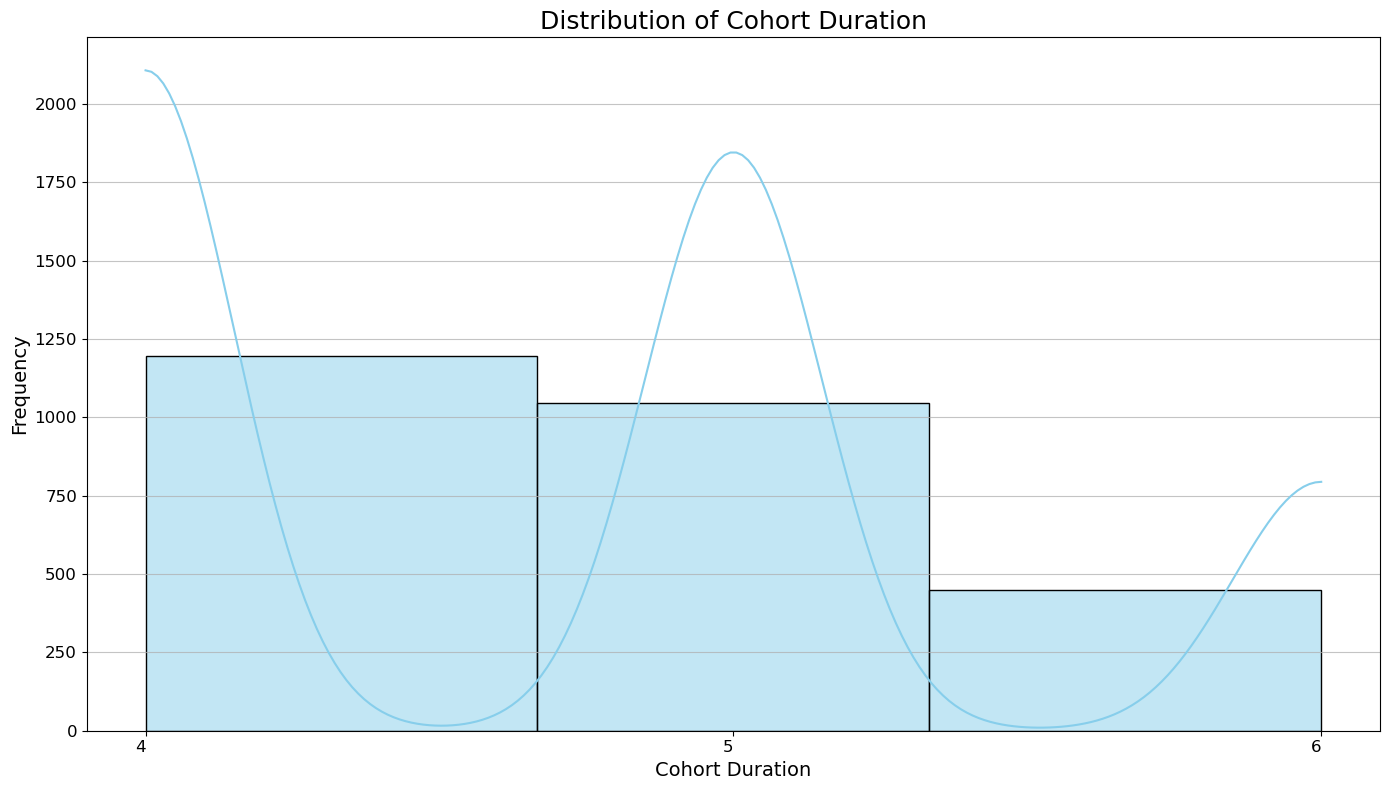

In [74]:
# Distribution of Cohort Duration
plt.figure(figsize=(14, 8))
sns.histplot(graduation['Cohort Duration'], kde=True, bins=3, color='skyblue')
plt.title('Distribution of Cohort Duration', fontsize=18)
plt.xlabel('Cohort Duration', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks([4, 5, 6], ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [75]:
graduation['# Total Cohort'] = graduation['# Total Cohort'].astype(int)

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/2571833090.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation['# Total Cohort'] = graduation['# Total Cohort'].astype(int)


In [76]:
graduation.describe()

,Cohort Year,Cohort Duration,# Total Cohort,% Grads,Graduation Year
count,2690.000000,2690.000000,2690.000000,2690.000000,2690.000000
mean,2015.126022,4.723420,4857.960595,78.270409,2019.849442
std,2.116914,0.731338,4771.260631,13.644792,2.118998
min,2012.000000,4.000000,7.000000,14.500000,2016.000000
25%,2013.000000,4.000000,1003.000000,73.200000,2018.000000
50%,2015.000000,5.000000,3097.000000,81.600000,2020.000000
75%,2017.000000,5.000000,7347.500000,87.800000,2022.000000
max,2019.000000,6.000000,18301.000000,98.800000,2023.000000


Average cohort size is over 5000 students

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/2711980118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation['% Dropout'] = pd.to_numeric(graduation['% Dropout'], errors='coerce')


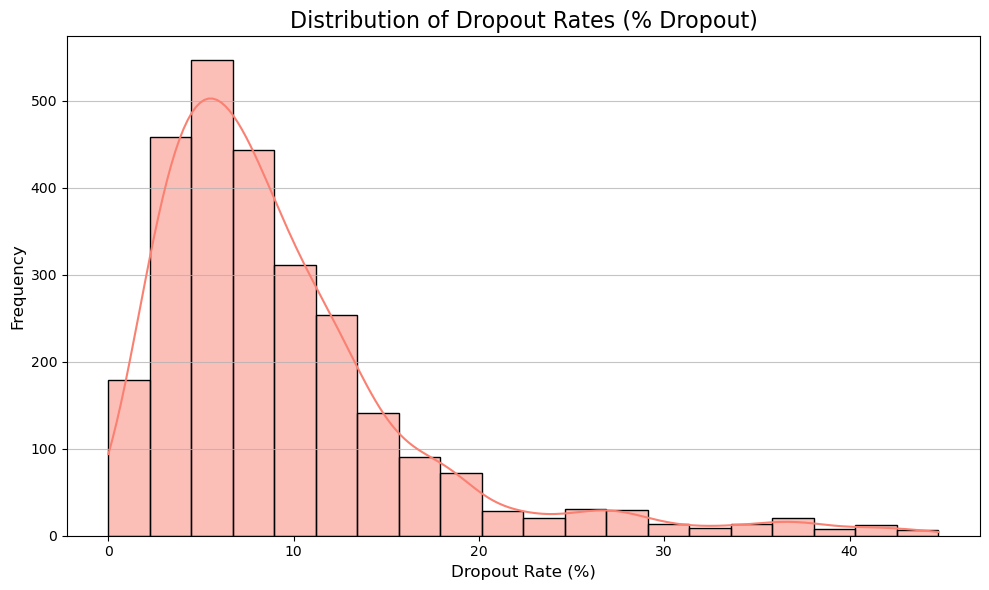

In [77]:
graduation['% Dropout'] = pd.to_numeric(graduation['% Dropout'], errors='coerce')
# Distribution of % Dropout
plt.figure(figsize=(10, 6))
sns.histplot(graduation['% Dropout'], kde=True, bins=20, color='salmon')
plt.title('Distribution of Dropout Rates (% Dropout)', fontsize=16)
plt.xlabel('Dropout Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Dropout rate has an average of 9%. Some cohorts had as high as 44%! Will explore this further.

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/1631653302.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation['% Advanced Regents of Cohort'] = pd.to_numeric(graduation['% Advanced Regents of Cohort'], errors='coerce')
/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/1631653302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graduation['% Advanced Regents of Grads'] = pd.to_numeric(graduation['% Advanced Regents of Grads'], errors='coerce')


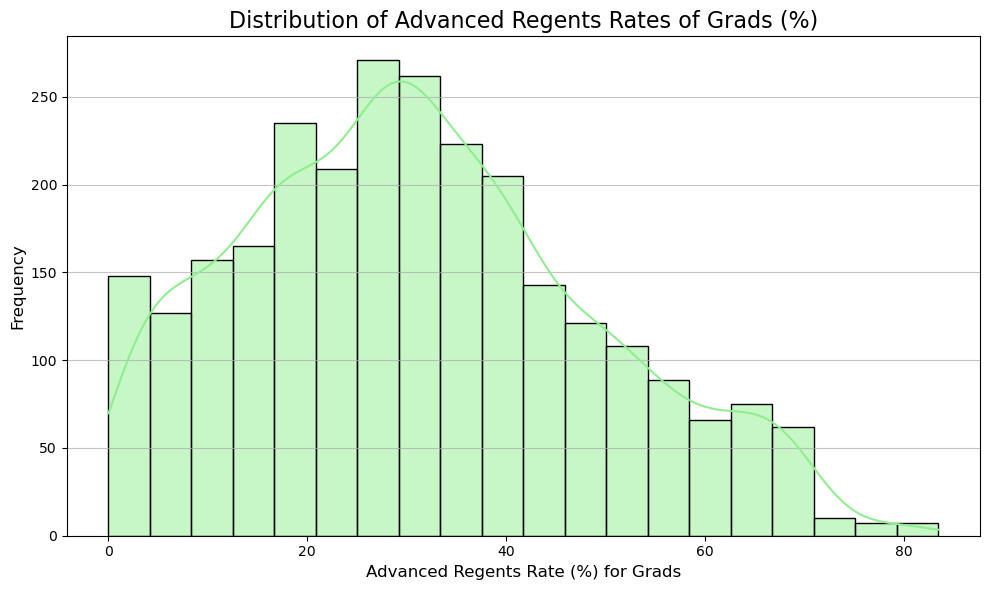

In [78]:
graduation['% Advanced Regents of Cohort'] = pd.to_numeric(graduation['% Advanced Regents of Cohort'], errors='coerce')
graduation['% Advanced Regents of Grads'] = pd.to_numeric(graduation['% Advanced Regents of Grads'], errors='coerce')
# Distribution of % Advanced Regents of Cohort
plt.figure(figsize=(10, 6))
sns.histplot(graduation['% Advanced Regents of Grads'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Advanced Regents Rates of Grads (%)', fontsize=16)
plt.xlabel('Advanced Regents Rate (%) for Grads', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Average % of Advanced Regents overall was 31% for grads

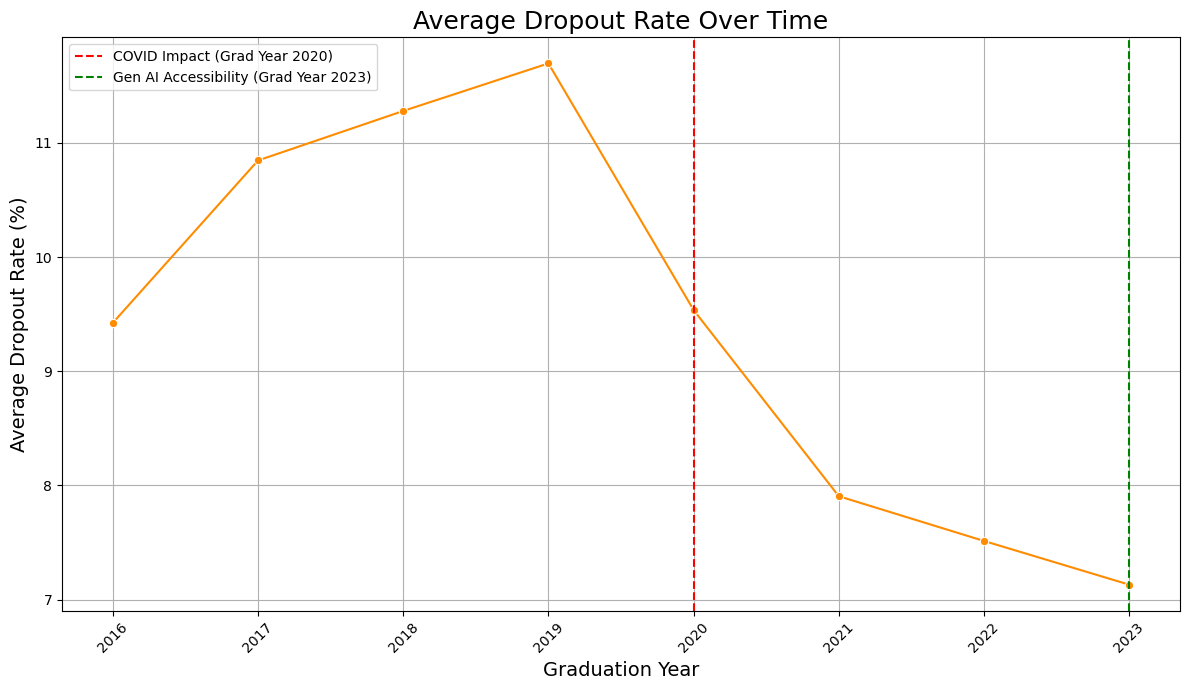

In [79]:
# Average % Dropout over Graduation Year
dropout_year_trends = graduation.groupby('Graduation Year')['% Dropout'].mean().reset_index()
plt.figure(figsize=(12, 7))
sns.lineplot(data=dropout_year_trends, x='Graduation Year', y='% Dropout', marker='o', color='darkorange')
plt.title('Average Dropout Rate Over Time', fontsize=18)
plt.xlabel('Graduation Year', fontsize=14)
plt.ylabel('Average Dropout Rate (%)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Very interesting insight. Average Dropout Rate percentages shows decrease over time. Will need to investigate more.

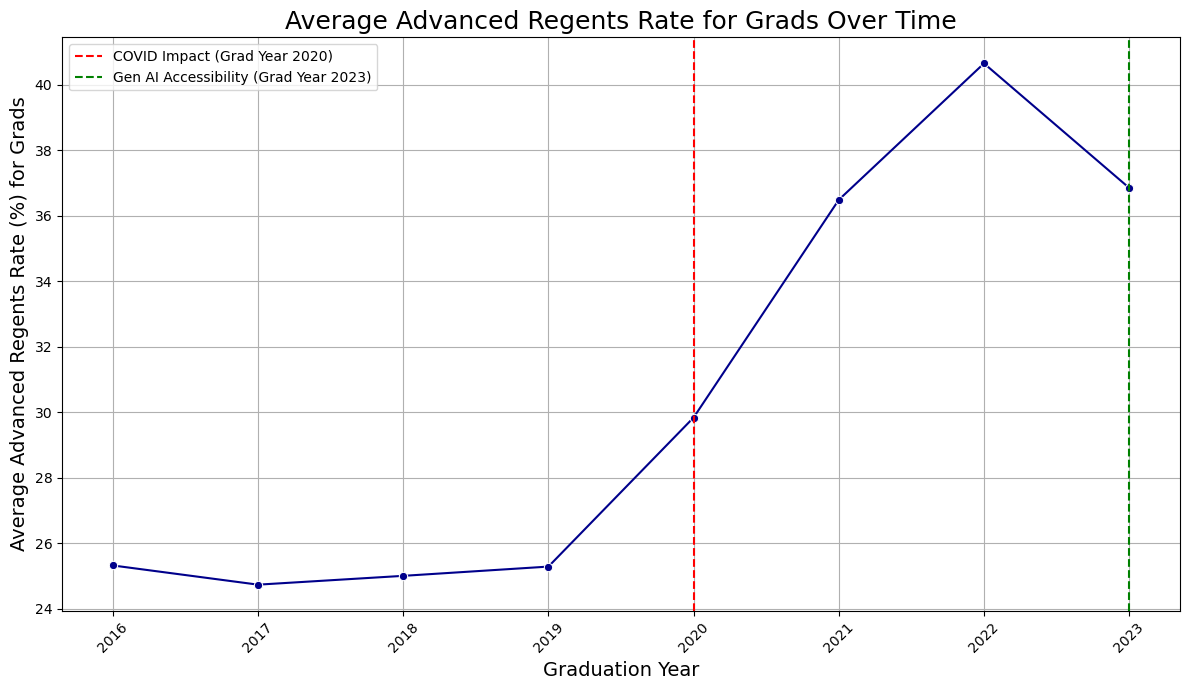

In [80]:
# Average % Advanced Regents of Grads over Graduation Year
adv_regents_year_trends = graduation.groupby('Graduation Year')['% Advanced Regents of Grads'].mean().reset_index()
plt.figure(figsize=(12, 7))
sns.lineplot(data=adv_regents_year_trends, x='Graduation Year', y='% Advanced Regents of Grads', marker='o', color='darkblue')
plt.title('Average Advanced Regents Rate for Grads Over Time', fontsize=18)
plt.xlabel('Graduation Year', fontsize=14)
plt.ylabel('Average Advanced Regents Rate (%) for Grads', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

I wonder what explains this trend. I find the decrease in 2023 to be especially interesting. Will need to investigate

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/4232777730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=graduation, x='Category', y='% Grads', palette='viridis', errorbar=None) # errorbar=None to remove confidence intervals


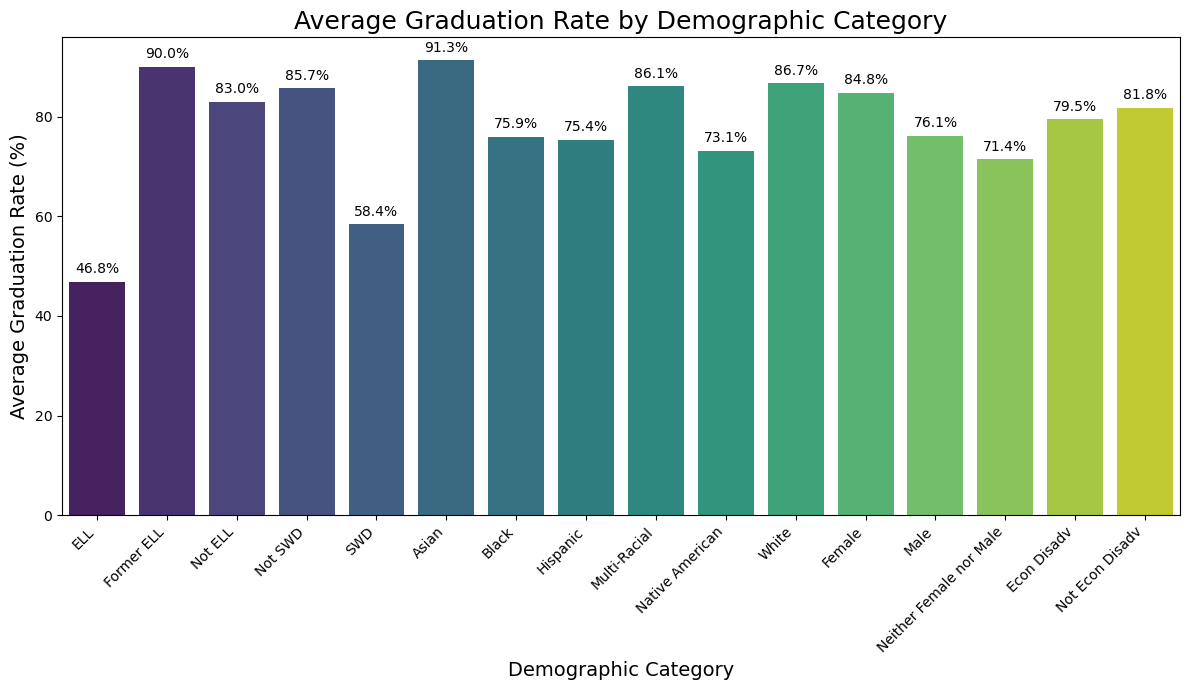

In [81]:
# Average % Grads by Demographic Category
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=graduation, x='Category', y='% Grads', palette='viridis', errorbar=None) # errorbar=None to remove confidence intervals
plt.title('Average Graduation Rate by Demographic Category', fontsize=18)
plt.xlabel('Demographic Category', fontsize=14)
plt.ylabel('Average Graduation Rate (%)', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
# Add percentage labels on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                color='black')
plt.tight_layout()
plt.show()

A lot of insights in this graph. I find the ELL status graduation trends to be interesting. Former ELL has the second highest graduation rate. Economic diversity doesn't seem to have much of a graduation gap. The lowest graduation rate groups are students with disabilities and and English Language Learners.

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/2754381271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=graduation, x='Category', y='% Dropout', palette='magma', errorbar=None)


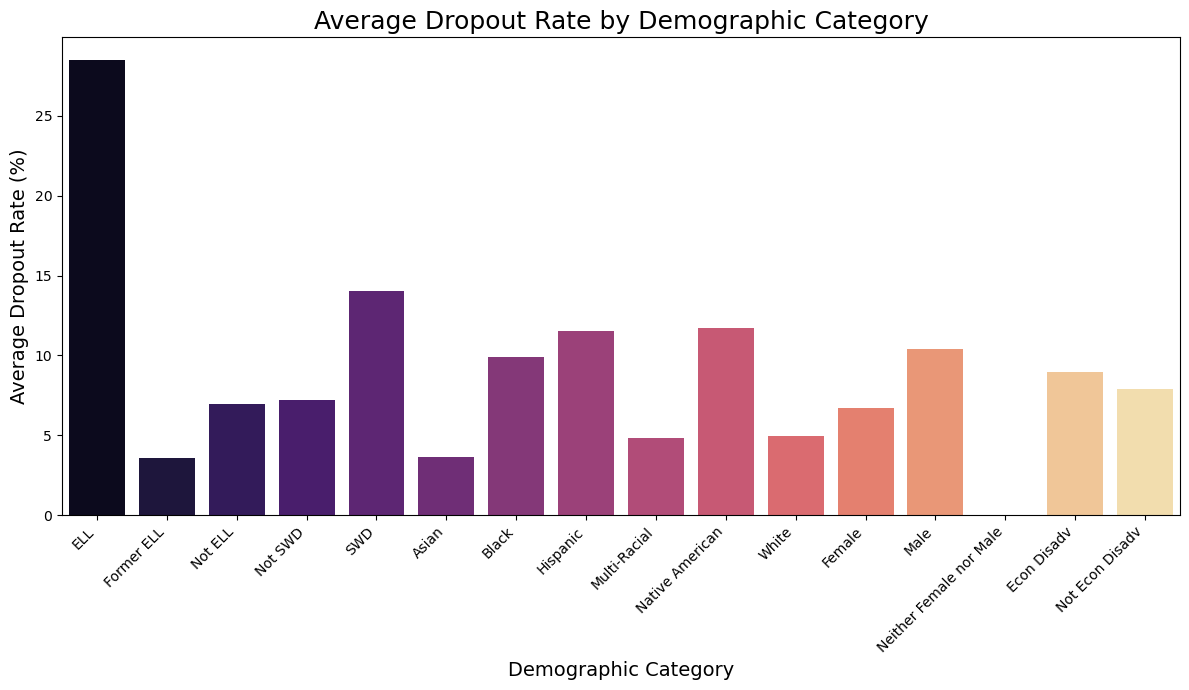

In [82]:
# Average % Dropout by Demographic Category
plt.figure(figsize=(12, 7))
sns.barplot(data=graduation, x='Category', y='% Dropout', palette='magma', errorbar=None)
plt.title('Average Dropout Rate by Demographic Category', fontsize=18)
plt.xlabel('Demographic Category', fontsize=14)
plt.ylabel('Average Dropout Rate (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Similar trends as previous graph

/var/folders/44/054jddgx76z1nm8vw2swwqmm0000gn/T/ipykernel_68003/181490064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=graduation, x='Category', y='% Advanced Regents of Grads', palette='cividis', errorbar=None)


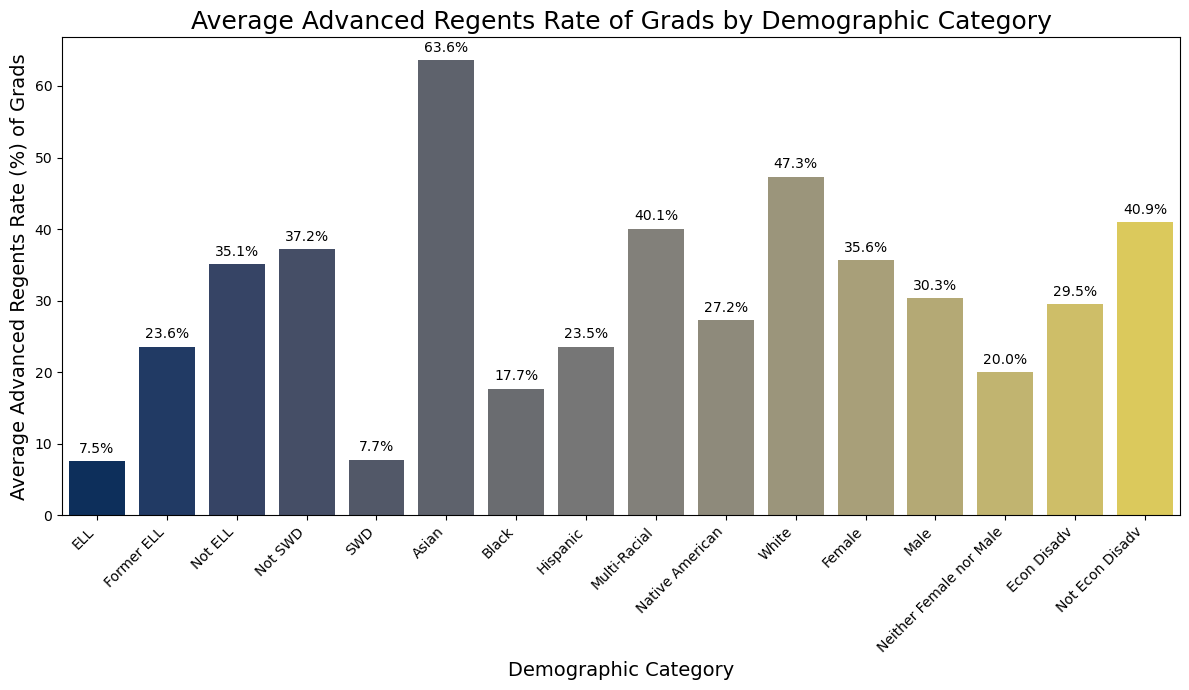

In [83]:
# Average % Advanced Regents of Grads by Demographic Category
plt.figure(figsize=(12, 7))
ax1 = sns.barplot(data=graduation, x='Category', y='% Advanced Regents of Grads', palette='cividis', errorbar=None)
plt.title('Average Advanced Regents Rate of Grads by Demographic Category', fontsize=18)
plt.xlabel('Demographic Category', fontsize=14)
plt.ylabel('Average Advanced Regents Rate (%) of Grads', fontsize=14)
plt.xticks(rotation=45, ha='right')
# Add percentage labels on each bar
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                color='black')
plt.tight_layout()
plt.show()

Larger gaps are more apparent here. Slightly different trends compared to the last two graphs. Lower advanced regent grad rates with econ disadvanatage. Asian ethnic group has the highest rate. English Language Learners and Students with Disabilities have the lowest. Maybe can focus on subcategories that went down. Important for future events!

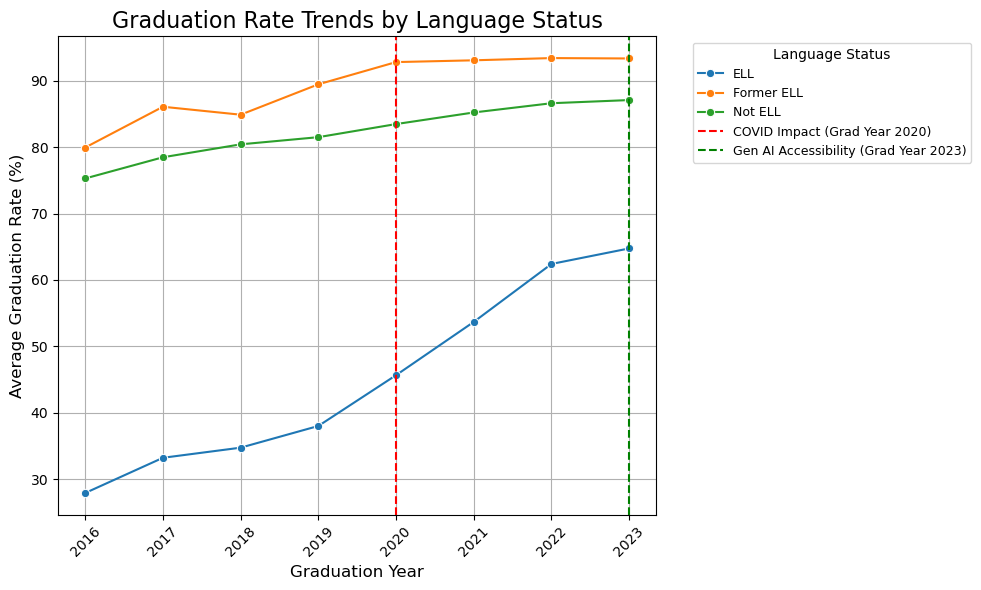

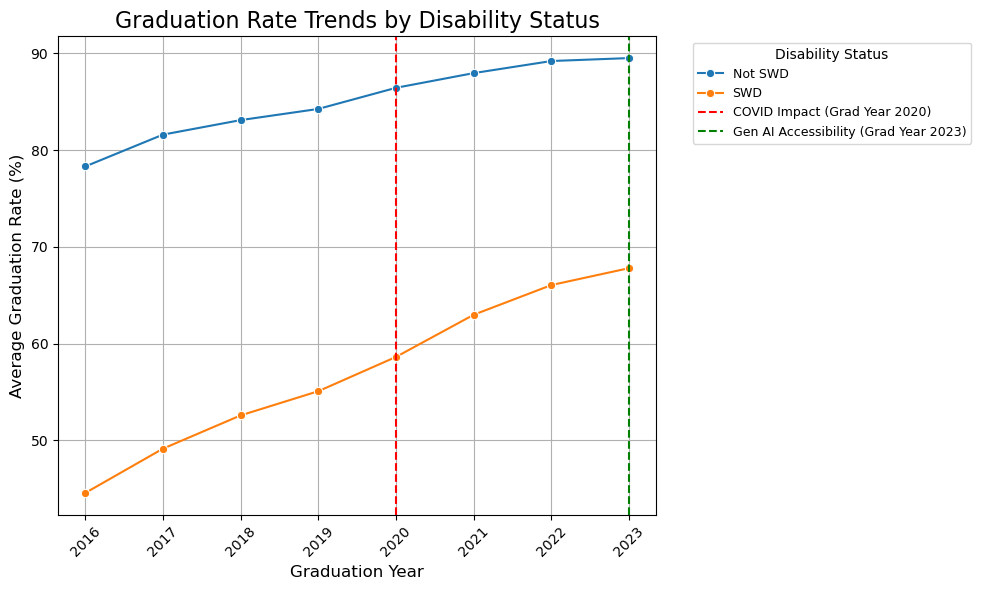

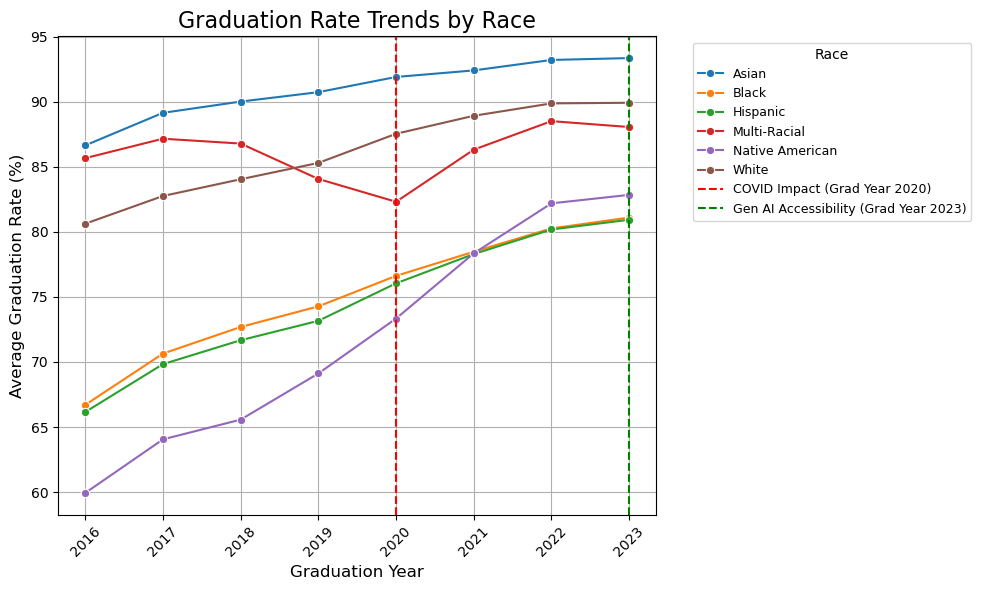

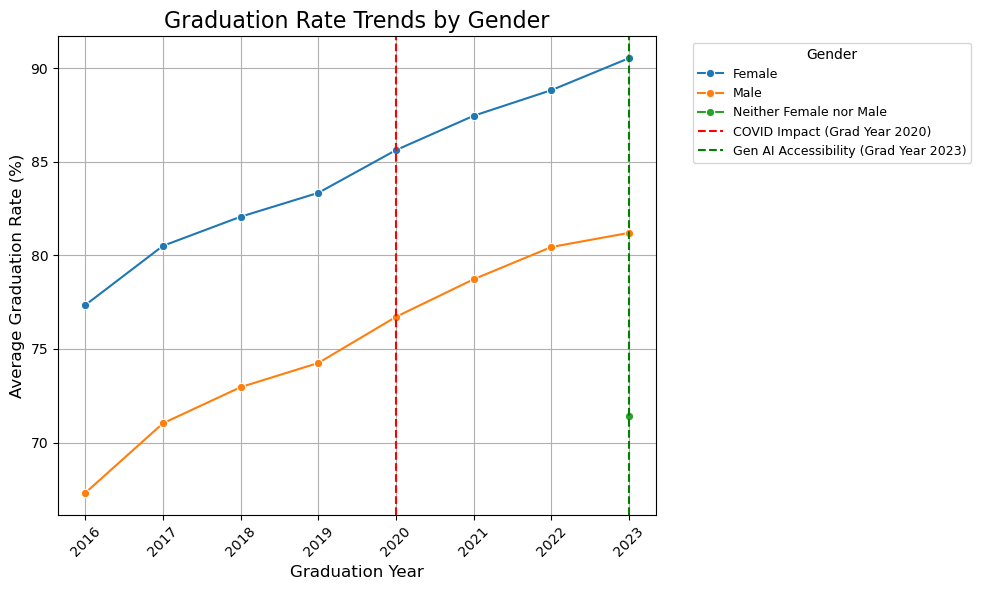

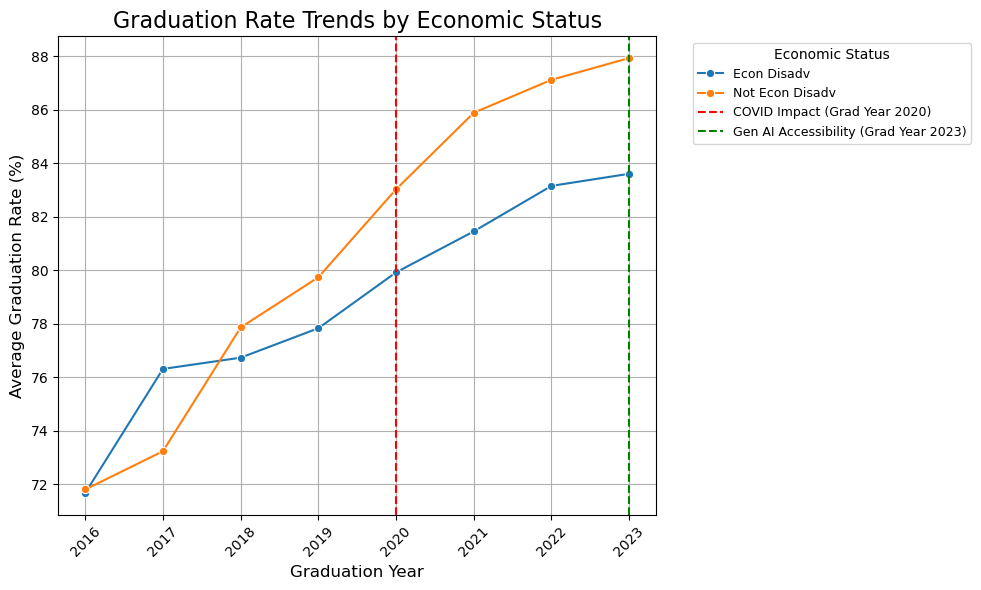

In [84]:
# Graduation Rate Trends by Demographic Category
# Define the categories and their respective groups
demographic_categories = {
    'Language Status': ['ELL', 'Former ELL', 'Not ELL'],
    'Disability Status': ['Not SWD', 'SWD'],
    'Race': ['Asian', 'Black', 'Hispanic', 'Multi-Racial', 'Native American', 'White'],
    'Gender': ['Female', 'Male', 'Neither Female nor Male'],
    'Economic Status': ['Econ Disadv', 'Not Econ Disadv']
}

for category_type, groups in demographic_categories.items():
    plt.figure(figsize=(10, 6)) # Adjust figure size for mini-graphs
    
    # Filter the DataFrame for the current demographic category
    df_filtered = graduation[graduation['Category'].isin(groups)].copy()

    sns.lineplot(data=df_filtered, x='Graduation Year', y='% Grads', hue='Category', marker='o', palette='tab10', errorbar=None)
    
    plt.title(f'Graduation Rate Trends by {category_type}', fontsize=16)
    plt.xlabel('Graduation Year', fontsize=12)
    plt.ylabel('Average Graduation Rate (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True)
    
    # Add vertical lines for COVID and Gen AI, if desired for mini-graphs
    plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
    plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')
    
    plt.legend(title=category_type, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.show()

Former ELL largest grad rate under Language status with ELL showing largest increase. Native American graduate rate surpassed Black and Hispanic during COVID and post. Does not seem to be much non-binary grad rate data until recently

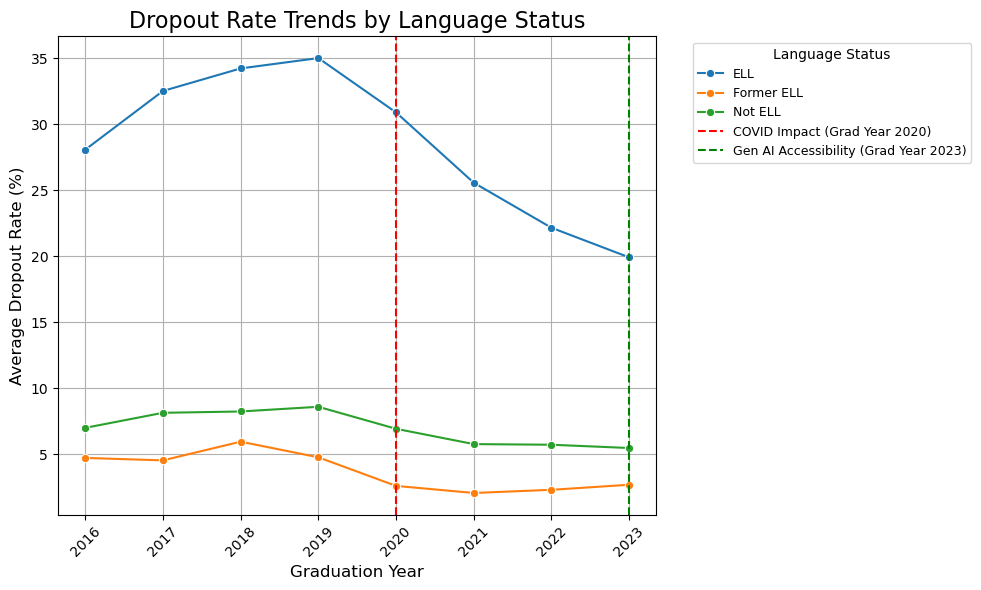

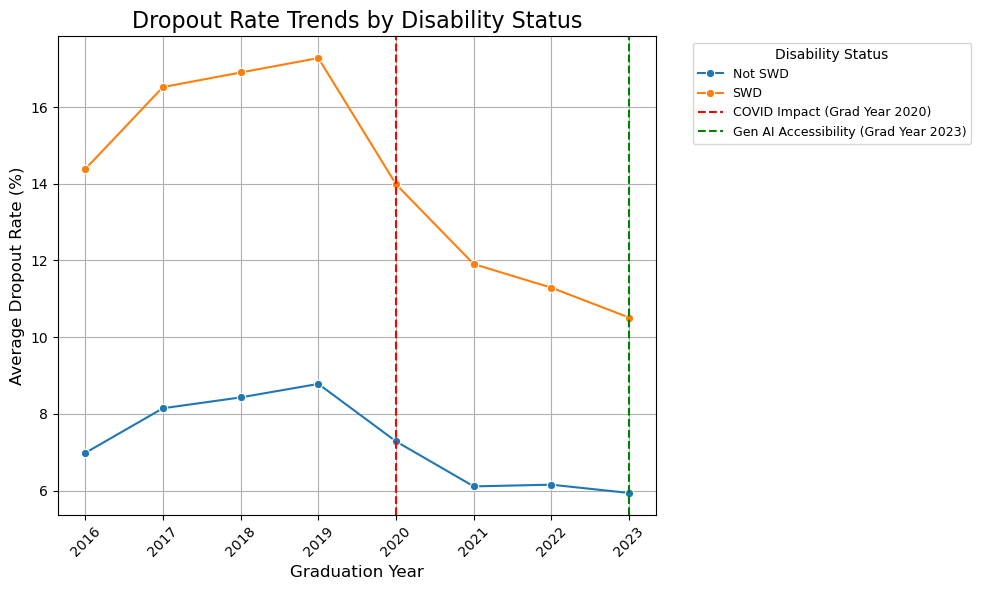

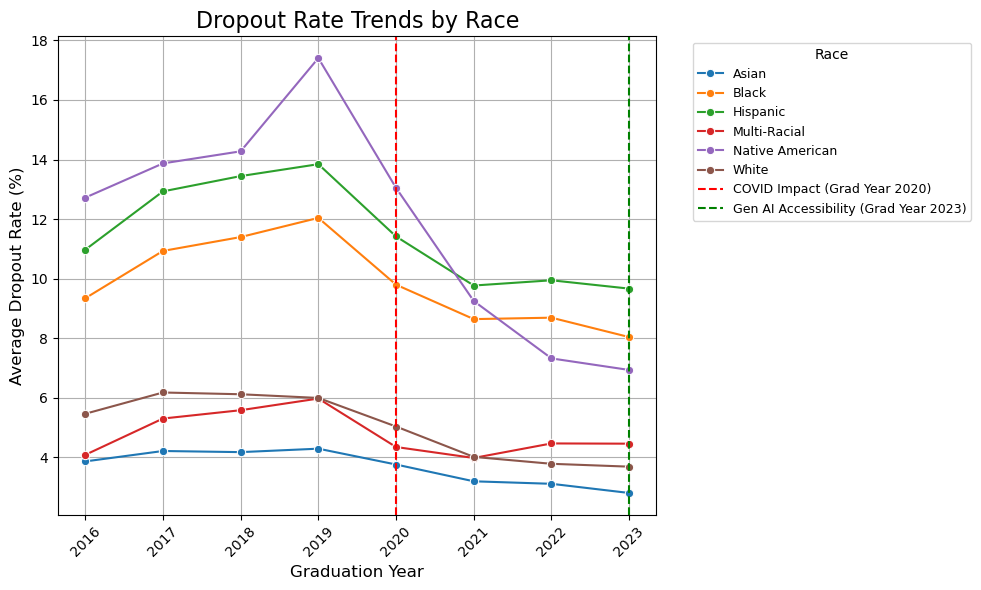

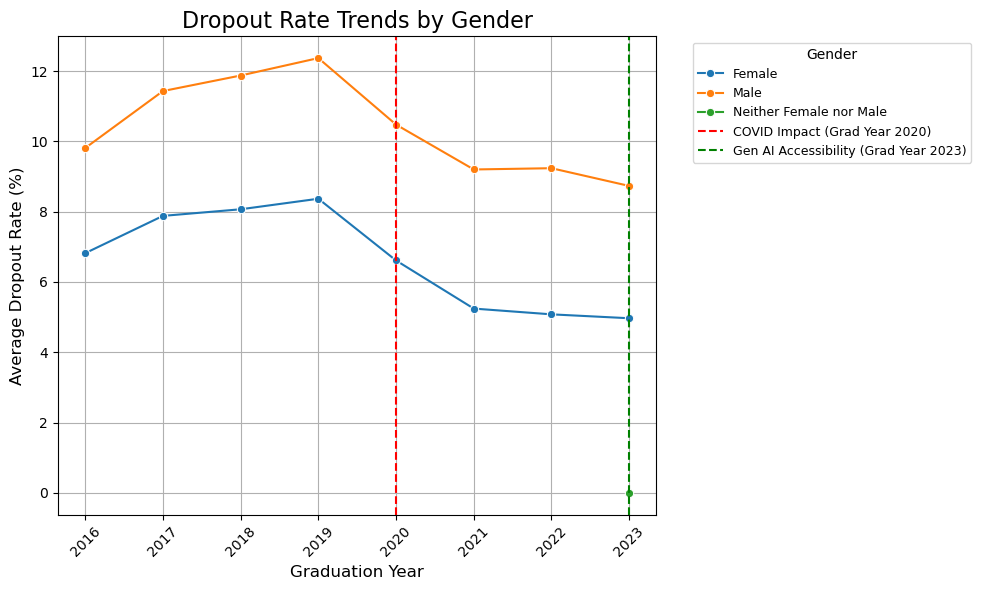

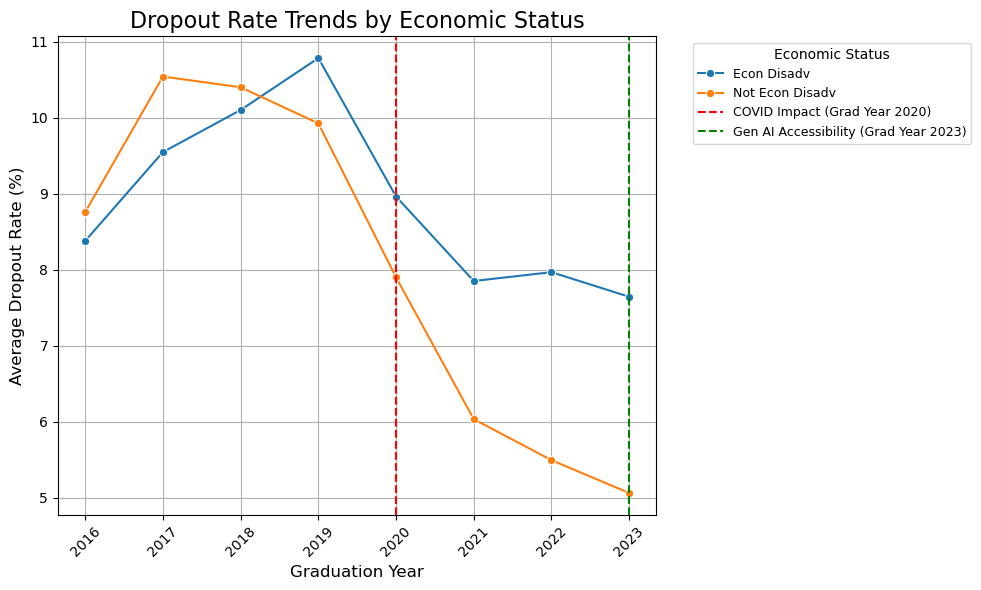

In [85]:
demographic_categories = {
    'Language Status': ['ELL', 'Former ELL', 'Not ELL'],
    'Disability Status': ['Not SWD', 'SWD'],
    'Race': ['Asian', 'Black', 'Hispanic', 'Multi-Racial', 'Native American', 'White'],
    'Gender': ['Female', 'Male', 'Neither Female nor Male'],
    'Economic Status': ['Econ Disadv', 'Not Econ Disadv']
}
for category_type, groups in demographic_categories.items():
    plt.figure(figsize=(10, 6)) # Adjust figure size for mini-graphs
    
    # Filter the DataFrame for the current demographic category
    df_filtered = graduation[graduation['Category'].isin(groups)].copy()

    sns.lineplot(data=df_filtered, x='Graduation Year', y='% Dropout', hue='Category', marker='o', palette='tab10', errorbar=None)
    
    plt.title(f'Dropout Rate Trends by {category_type}', fontsize=16)
    plt.xlabel('Graduation Year', fontsize=12)
    plt.ylabel('Average Dropout Rate (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True)
    
    # Add vertical lines for COVID and Gen AI, if desired for mini-graphs
    plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
    plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')
    
    plt.legend(title=category_type, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.show()

ELL dropout rate decreased a lot during covid and post. Multiracial surpassed White during Covid and post.

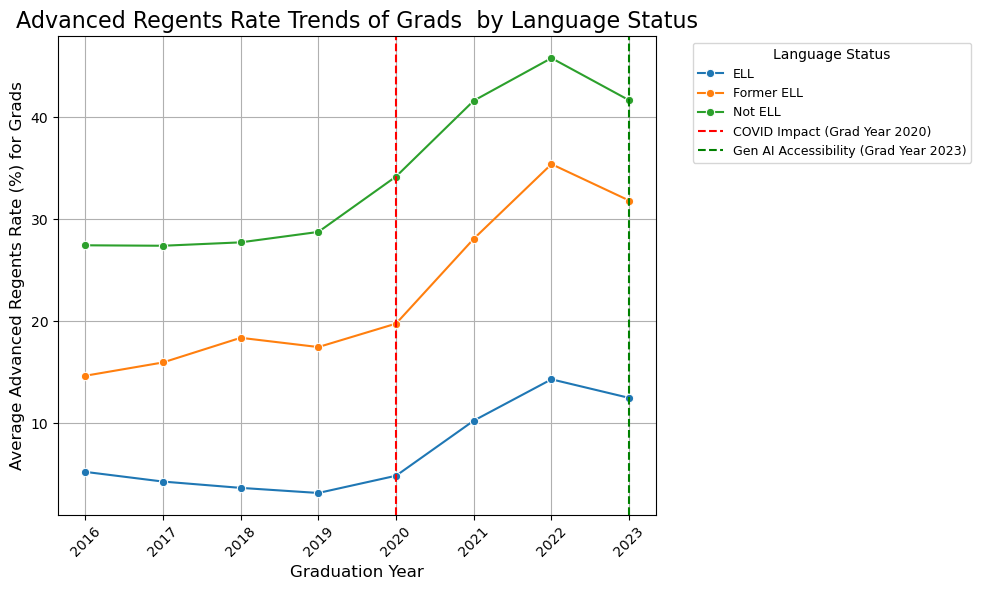

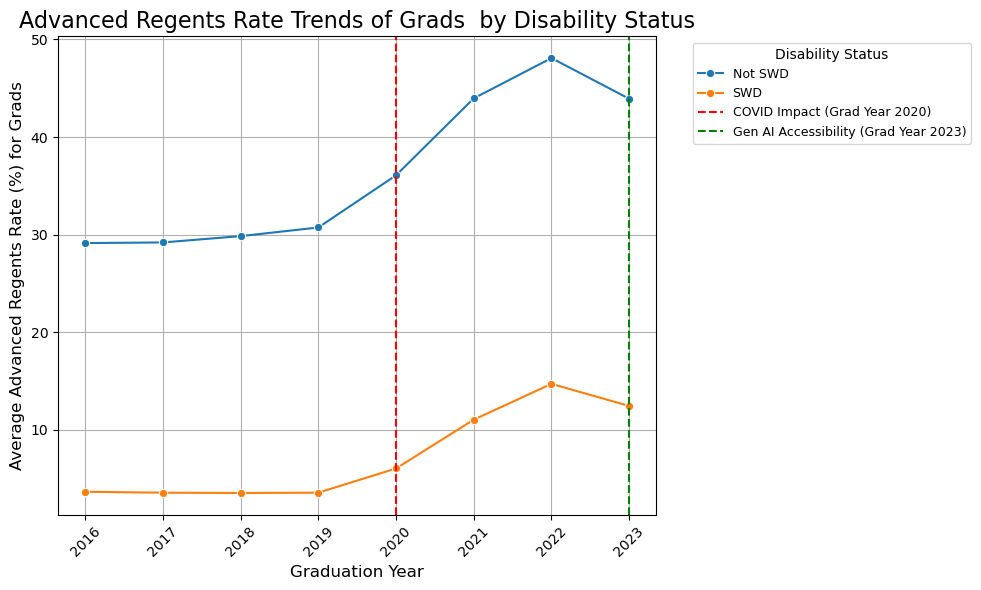

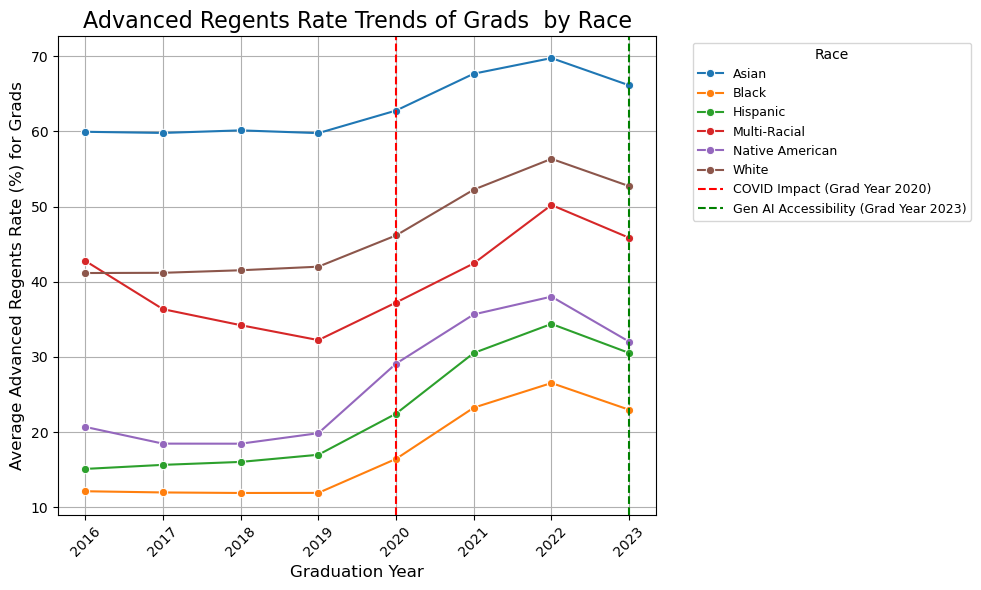

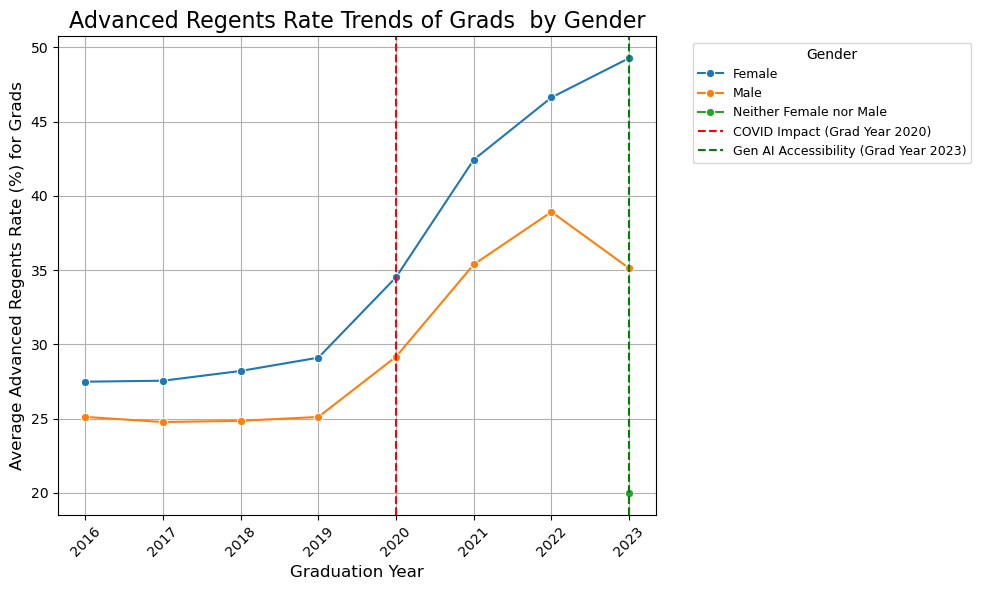

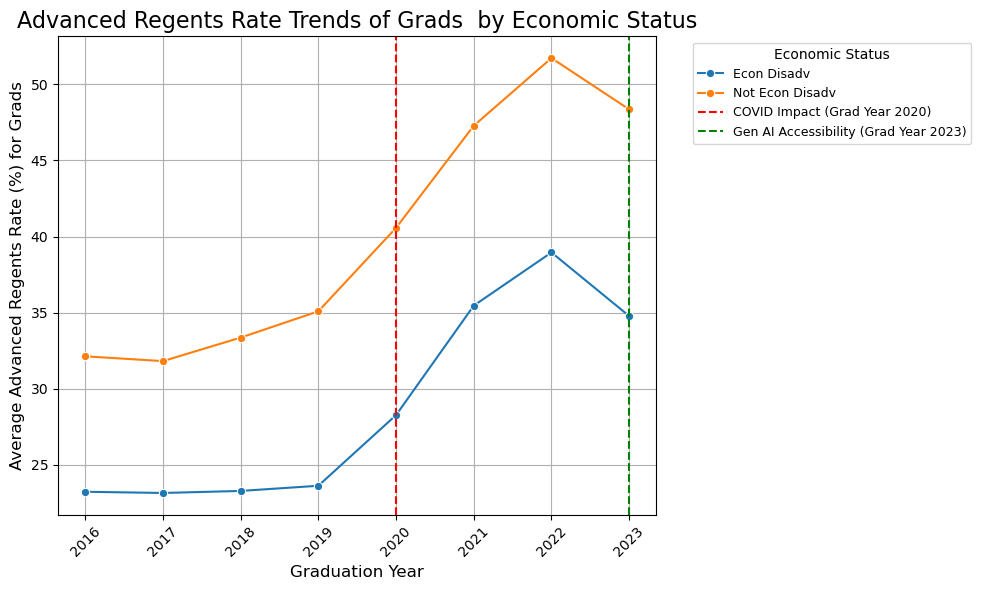

In [86]:
# Advanced Regents Rate Trends for Grads by Demographic Category
# Define the categories and their respective groups
demographic_categories = {
    'Language Status': ['ELL', 'Former ELL', 'Not ELL'],
    'Disability Status': ['Not SWD', 'SWD'],
    'Race': ['Asian', 'Black', 'Hispanic', 'Multi-Racial', 'Native American', 'White'],
    'Gender': ['Female', 'Male', 'Neither Female nor Male'],
    'Economic Status': ['Econ Disadv', 'Not Econ Disadv']
}

for category_type, groups in demographic_categories.items():
    plt.figure(figsize=(10, 6)) # Adjust figure size for mini-graphs
    
    # Filter the DataFrame for the current demographic category
    df_filtered = graduation[graduation['Category'].isin(groups)].copy()

    sns.lineplot(data=df_filtered, x='Graduation Year', y='% Advanced Regents of Grads', hue='Category', marker='o', palette='tab10', errorbar=None)
    
    plt.title(f'Advanced Regents Rate Trends of Grads  by {category_type}', fontsize=16)
    plt.xlabel('Graduation Year', fontsize=12)
    plt.ylabel('Average Advanced Regents Rate (%) for Grads', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True)
    
    # Add vertical lines for COVID and Gen AI
    plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
    plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')
    
    plt.legend(title=category_type, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.show()

Language status disparities show for grads with advanced regents. When AI became accesible, female students increased, while male decreased.

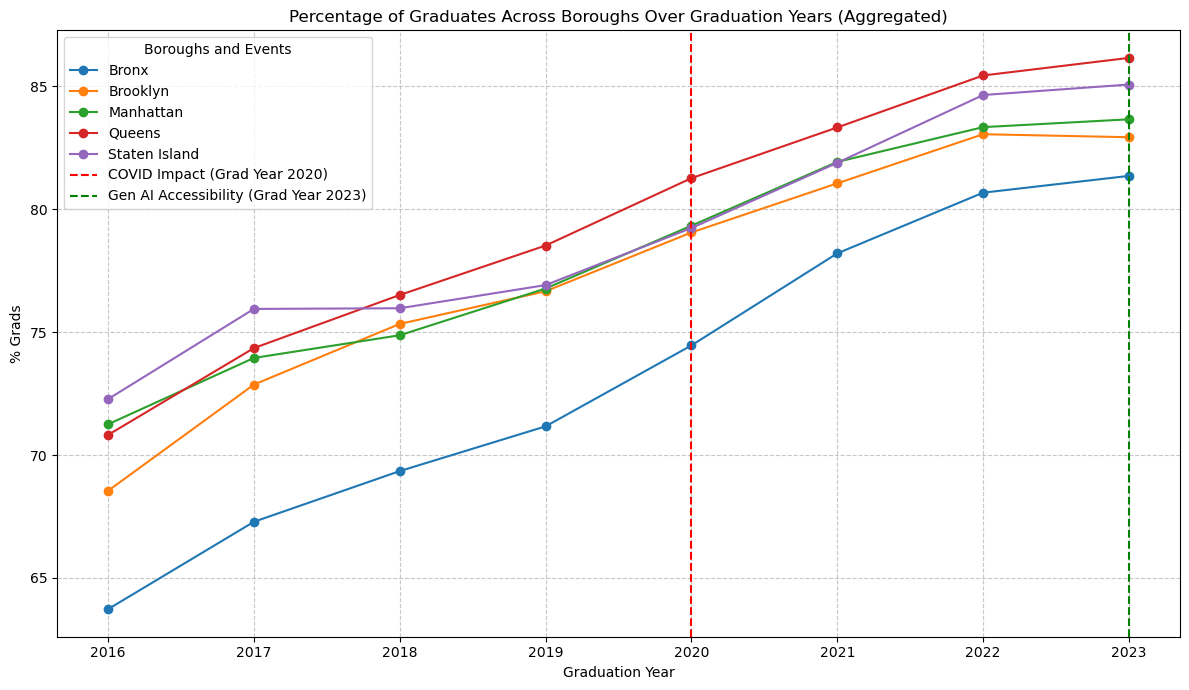

In [87]:
graduation_agg = graduation.groupby(['Borough', 'Graduation Year'])['% Grads'].mean().reset_index()


plt.figure(figsize=(12, 7))

# Get unique boroughs to iterate and plot
boroughs = graduation_agg['Borough'].unique()

for borough in boroughs:
    # Filter data for the current borough from the aggregated DataFrame
    borough_data = graduation_agg[graduation_agg['Borough'] == borough]
    # Plot '% Grads' vs 'Graduation Year' for the current borough
    plt.plot(borough_data['Graduation Year'], borough_data['% Grads'], marker='o', label=f'{borough}')

plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')


plt.xlabel('Graduation Year')
plt.ylabel('% Grads')
plt.title('Percentage of Graduates Across Boroughs Over Graduation Years (Aggregated)')
plt.xticks(graduation_agg['Graduation Year'].unique()) # Ensure all graduation years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7) 
plt.legend(title='Boroughs and Events')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Queens has highest grad rate with Bronx as lowest. Brooklyn showed minor decrease in graduation rate in AI year.

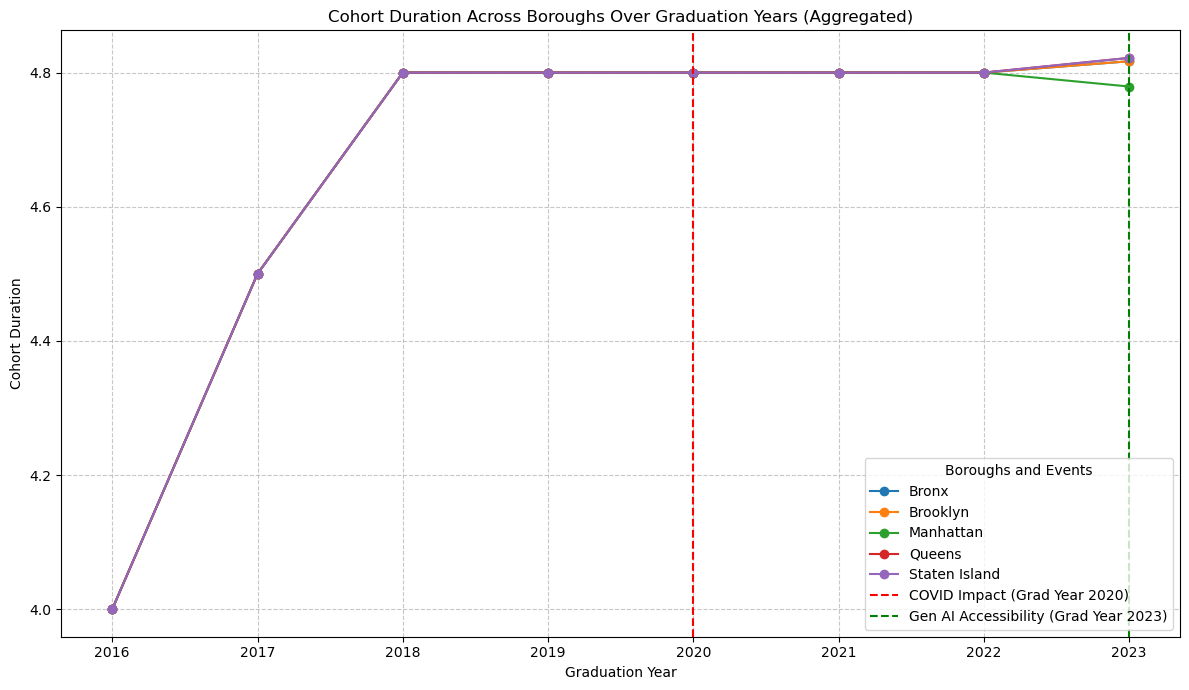

In [88]:
# Aggregate the data to get the mean Cohort Duration for each Borough and Graduation Year
# This ensures only one data point (and thus one line) per borough per year.
graduation_agg = graduation.groupby(['Borough', 'Graduation Year'])['Cohort Duration'].mean().reset_index()


plt.figure(figsize=(12, 7)) 

boroughs = graduation_agg['Borough'].unique()

for borough in boroughs:
    # Filter data for the current borough from the aggregated DataFrame
    borough_data = graduation_agg[graduation_agg['Borough'] == borough]
    # Plot 'Cohort Duration' vs 'Graduation Year' for the current borough
    plt.plot(borough_data['Graduation Year'], borough_data['Cohort Duration'], marker='o', label=f'{borough}')

plt.axvline(x=2020, color='red', linestyle='--', label='COVID Impact (Grad Year 2020)')
plt.axvline(x=2023, color='green', linestyle='--', label='Gen AI Accessibility (Grad Year 2023)')

plt.xlabel('Graduation Year')
plt.ylabel('Cohort Duration')
plt.title('Cohort Duration Across Boroughs Over Graduation Years (Aggregated)')
plt.xticks(graduation_agg['Graduation Year'].unique()) # Ensure all graduation years are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend(title='Boroughs and Events') # Display the legend
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Manhattan slightly decreased for graduation length in AI introduction year.

Transformations Summary

For the graduation dataset, I completed the following transformations;

Dropped suppressed data to further support the Family Educational Rights and Privacy Act (FERPA) and be able to analyze the numerical columns.
Dropped 5 rows that didn't include any additional data
Created Graduation Year column
Datatype conversions for visuals since a lot of the original data types were object
Created Cohort Duration column
Dropped "All Students" rows